In [1]:
setwd("/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb")
library(ggplot2)
library(ggrepel)
library(ggrastr)
library(data.table)
library(dplyr)
library(latex2exp)
devtools::load_all('utils/modules/R/gwastools')


Attaching package: 'dplyr'


The following objects are masked from 'package:data.table':

    between, first, last


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


i Loading gwastools

Loading required package: stringr

Warning message in setup_ns_exports(path, export_all, export_imports):
"Objects listed as exports, but not present in namespace: summarize_bcftools_trio_stats"


In [19]:
files <- list.files('data/saige//output//cts//step2_set//min_mac4', pattern = '.txt.gz', full.names = TRUE)

In [26]:
files <- list.files('data/saige/output/cts/step2/min_mac4', pattern = '.txt.gz', full.names = TRUE)

In [27]:
files

character(0)

In [22]:
d <- fread("data/saige//output//cts//step2_set//min_mac4/ukb_eur_wes_200k_annot_maf0to5e-2_Apolipoprotein_A_residual_pLoF_damaging_missense.txt.gz")

In [23]:
head(d)

Region,Group,max_MAF,Pvalue,Pvalue_Burden,Pvalue_SKAT,BETA_Burden,SE_Burden,MAC,Number_rare,Number_ultra_rare
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>
ENSG00000187634,pLoF,0.001,0.1046344,0.1407494,0.07227102,-0.0074542183,0.0050605480,63,1,7
ENSG00000187634,pLoF,0.010,0.1046344,0.1407494,0.07227102,-0.0074542183,0.0050605480,63,1,7
ENSG00000187634,damaging_missense,0.001,0.5732696,0.5732696,0.57326965,-0.0075109902,0.0133352648,9,0,2
ENSG00000187634,damaging_missense,0.010,0.5732696,0.5732696,0.57326965,-0.0075109902,0.0133352648,9,0,2
ENSG00000187634,synonymous,0.001,0.6162825,0.6625738,0.39605640,0.0004485994,0.0010280432,1560,39,53
ENSG00000187634,synonymous,0.010,0.8109497,0.6007234,0.64579957,0.0003092520,0.0005908968,4980,45,53


In [11]:
d <- fread("data/saige//output//cts//step2_set//min_mac4/ukb_eur_wes_200k_annot_maf0to5e-2_WHR_adj_BMI_pLoF_damaging_missense_locoprs.txt.gz")
#d <- fread(files[1])
d[is.na(d$max_MAF),] <- 1
#d$max_MAF[is.na(d$max_MAF)] <- 1

In [12]:
head(files)

[1] "data/saige//output//cts//step2_set//min_mac4/ukb_eur_wes_200k_annot_maf0to5e-2_Alanine_aminotransferase_residual_pLoF_damaging_missense.txt.gz"  
[2] "data/saige//output//cts//step2_set//min_mac4/ukb_eur_wes_200k_annot_maf0to5e-2_Albumin_residual_pLoF_damaging_missense.txt.gz"                   
[3] "data/saige//output//cts//step2_set//min_mac4/ukb_eur_wes_200k_annot_maf0to5e-2_Alkaline_Phosphatase_residual_pLoF_damaging_missense.txt.gz"      
[4] "data/saige//output//cts//step2_set//min_mac4/ukb_eur_wes_200k_annot_maf0to5e-2_Apolipoprotein_A_residual_pLoF_damaging_missense.txt.gz"          
[5] "data/saige//output//cts//step2_set//min_mac4/ukb_eur_wes_200k_annot_maf0to5e-2_Apolipoprotein_B_residual_pLoF_damaging_missense.txt.gz"          
[6] "data/saige//output//cts//step2_set//min_mac4/ukb_eur_wes_200k_annot_maf0to5e-2_Aspartate_aminotransferase_residual_pLoF_damaging_missense.txt.gz"

In [13]:
all_groups <- unique(d$Group)
all_mafs <- unique(d$max_MAF)
ribbon_p <- 0.95

In [14]:
lst <- lapply(all_mafs, function(m){
    lapply(all_groups, function(g){
        bool_maf <- d$max_MAF %in% m
        bool_group <- d$Group %in% g
        dt <- d[bool_maf & bool_group,]
        n <- nrow(dt)
        if (n > 0){
            #dt <- dt[order(dt$Pvalue),]
            #dt$Pvalue_expected <- get_expected_p(dt$Pvalue)
            #dt$Pvalue_expected_nlog10 = -log10(sort(dt$Pvalue_expected))
            #dt$clower = -log10(qbeta(p = (1 - ribbon_p) / 2, shape2 = n:1, shape1 = 1:n))
            #dt$cupper = -log10(qbeta(p = (1 + ribbon_p) / 2, shape2 = n:1, shape1 = 1:n))
            
            dt[, Burden := ifelse(is.na(Pvalue_Burden), -log10(Pvalue), -log10(Pvalue_Burden))]
            dt[, SKAT := ifelse(is.na(Pvalue_SKAT), -log10(Pvalue), -log10(Pvalue_SKAT))]
            dt[, `SKAT-O` := -log10(Pvalue)]
            
            
            dt <- melt(
                dt, 
                id.vars = c("Region", "Group", "max_MAF"), 
                measure.vars = c("Burden", "SKAT", "SKAT-O"), 
                variable.name = "test", 
                value.name = "Pvalue"
            )
            dt <- data.table(
                dt %>% arrange(test, desc(Pvalue)) %>% select(-test),
                dt %>% group_by(test) %>% arrange(desc(Pvalue)) %>% 
                    summarize(
                    Pvalue_expected = -log10(seq(1, n())/(n() + 1)),
                    clower = -log10(qbeta(p = (1 - ribbon_p) / 2, shape2 = n():1, shape1 = 1:n())),
                    cupper = -log10(qbeta(p = (1 + ribbon_p) / 2, shape2 = n():1, shape1 = 1:n()))
                    )
                )

            return(dt)
        }
    })
    
})

`summarise()` has grouped output by 'test'. You can override using the `.groups` argument.

`summarise()` has grouped output by 'test'. You can override using the `.groups` argument.

`summarise()` has grouped output by 'test'. You can override using the `.groups` argument.

`summarise()` has grouped output by 'test'. You can override using the `.groups` argument.

`summarise()` has grouped output by 'test'. You can override using the `.groups` argument.

`summarise()` has grouped output by 'test'. You can override using the `.groups` argument.

`summarise()` has grouped output by 'test'. You can override using the `.groups` argument.

`summarise()` has grouped output by 'test'. You can override using the `.groups` argument.

`summarise()` has grouped output by 'test'. You can override using the `.groups` argument.

`summarise()` has grouped output by 'test'. You can override using the `.groups` argument.

`summarise()` has grouped output by 'test'. You can override using the `.groups`

In [15]:
dt <- do.call(rbind, do.call(rbind, lst))

In [16]:
head(dt[rev(order(dt$Pvalue)),], n = 10)


Region,Group,max_MAF,Pvalue,test,Pvalue_expected,clower,cupper
<chr>,<chr>,<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>
ENSG00000277322,synonymous;damaging_missense;pLoF,0.010,NA,SKAT-O,2.468073e-05,9.104683e-05,6.248798e-07
ENSG00000277322,synonymous;damaging_missense;pLoF,0.010,NA,SKAT,2.468073e-05,9.104683e-05,6.248798e-07
ENSG00000277322,synonymous;damaging_missense;pLoF,0.010,NA,Burden,2.468073e-05,9.104683e-05,6.248798e-07
ENSG00000277322,synonymous;damaging_missense;pLoF,0.001,NA,SKAT-O,2.468775e-05,9.107271e-05,6.250574e-07
ENSG00000277322,synonymous;damaging_missense;pLoF,0.001,NA,SKAT,2.468775e-05,9.107271e-05,6.250574e-07
ENSG00000277322,synonymous;damaging_missense;pLoF,0.001,NA,Burden,2.468775e-05,9.107271e-05,6.250574e-07
ENSG00000277322,synonymous,0.010,NA,SKAT-O,2.472147e-05,9.119713e-05,6.259113e-07
ENSG00000277322,synonymous,0.010,NA,SKAT,2.472147e-05,9.119713e-05,6.259113e-07
ENSG00000277322,synonymous,0.010,NA,Burden,2.472147e-05,9.119713e-05,6.259113e-07


Warning message:
"Removed 12 rows containing missing values (geom_point)."


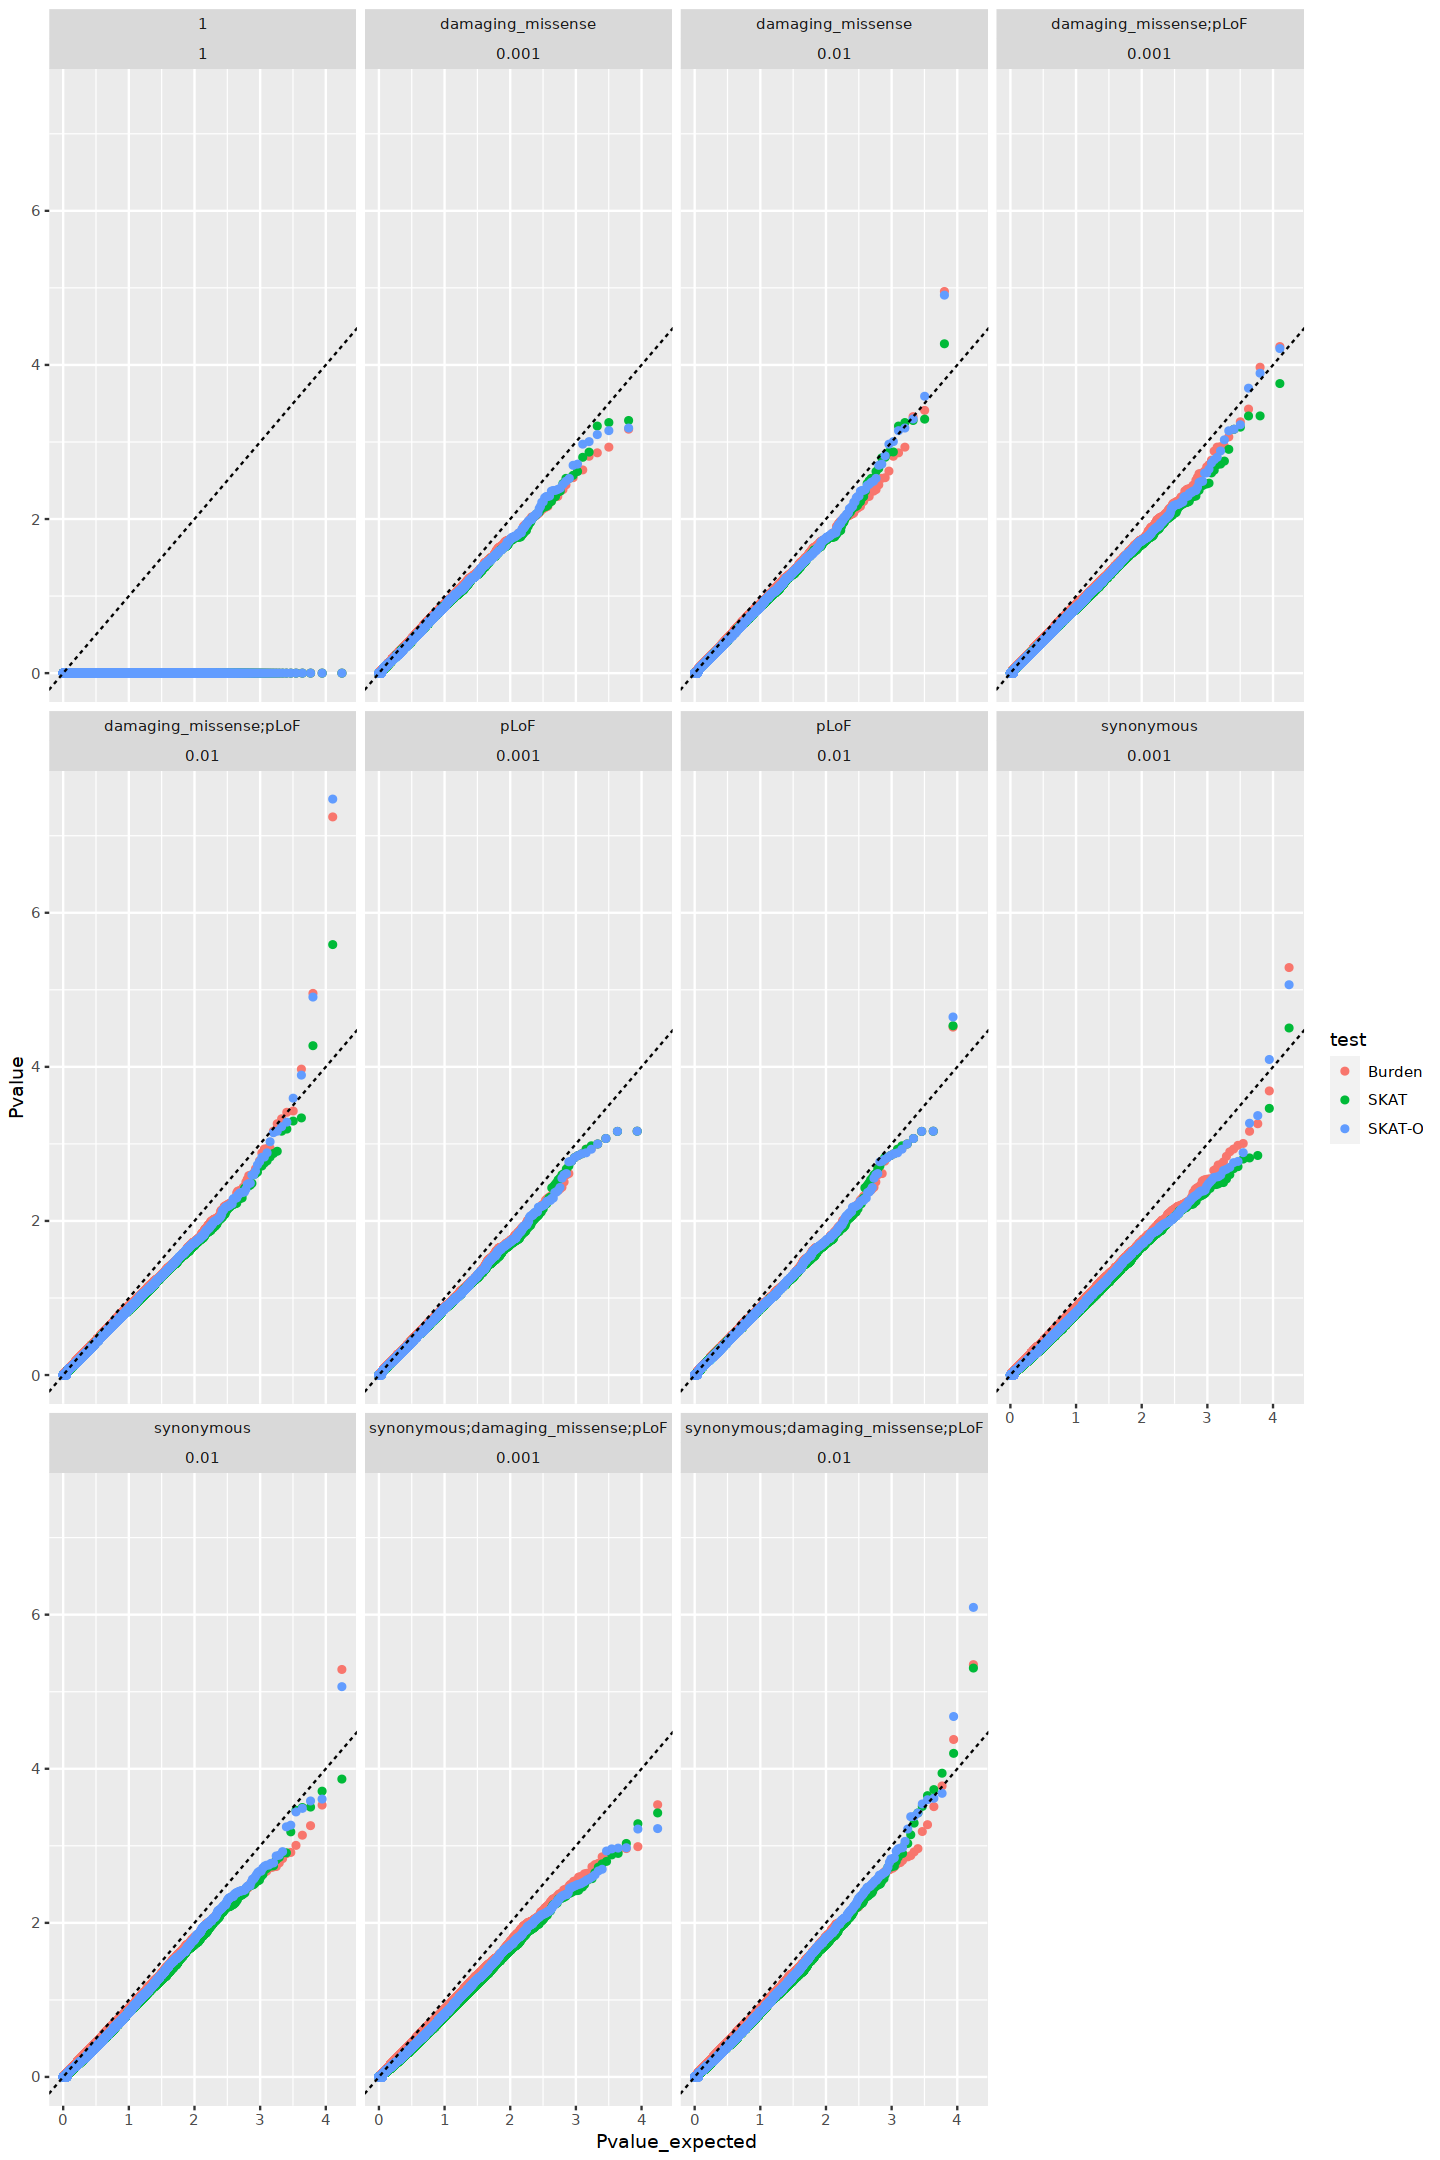

In [17]:
options(repr.plot.width=12, repr.plot.height=18)
ggplot(dt, aes(x=Pvalue_expected, y=Pvalue, color = test)) +
    geom_point() +
    geom_abline(intercept=0, slope=1, linetype = 'dashed') +
    facet_wrap(Group ~ max_MAF)

In [18]:
TeX("$-\\log_{10}(\\mathit{p}_{expected})$")

   LaTeX: $-\log_{10}(\mathit{p}_{expected})$ 
plotmath: phantom() - log[10](mathit * {p}[expected]) 

Creating scatter-plot...
                Region Group max_MAF   Pvalue   test Pvalue_expected
    1: ENSG00000186118  pLoF    0.01 0.000000 Burden     0.002730785
    2: ENSG00000005436  pLoF    0.01 0.000000 Burden     0.002680058
    3: ENSG00000136696  pLoF    0.01 0.000000 Burden     0.002629338
    4: ENSG00000163482  pLoF    0.01 0.000000 Burden     0.002578623
    5: ENSG00000185404  pLoF    0.01 0.000000 Burden     0.002527914
   ---                                                              
25838: ENSG00000117983  pLoF    0.01 2.998825 SKAT-O     3.236285277
25839: ENSG00000100473  pLoF    0.01 3.070037 SKAT-O     3.333195290
25840: ENSG00000213551  pLoF    0.01 3.162216 SKAT-O     3.458134027
25841: ENSG00000181061  pLoF    0.01 3.164820 SKAT-O     3.634225286
25842: ENSG00000152270  pLoF    0.01 4.647138 SKAT-O     3.935255282
            clower      cupper          labels
    1: 0.003505992 0.002051568 ENSG00000186118
    2: 0.003448430 0.002007664 ENSG00000005436
    3:

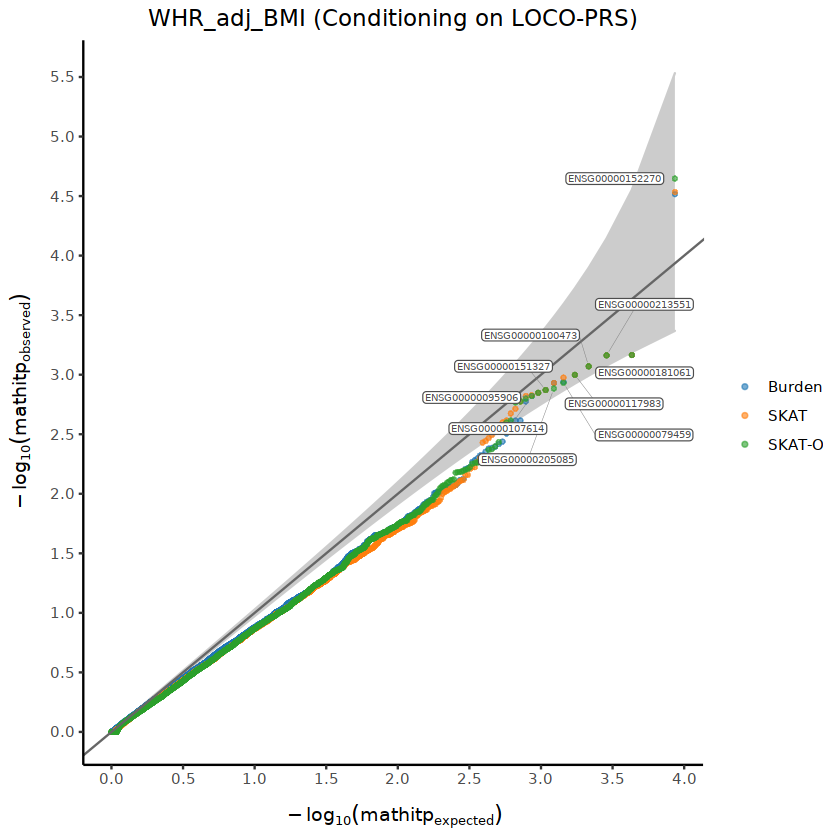

In [169]:
test = create_pretty_qq_plot(
				plot_title="WHR_adj_BMI (Conditioning on LOCO-PRS)",
				cex_labels=2,
				dt %>% mutate(labels=Region), aes(x=Pvalue_expected, y=Pvalue, color=test),
				save_figure=FALSE, n_to_include=10,
				x_label=TeX("$-\\log_{10}(\\mathit{p}_{expected})$"), 
				y_label=TeX("$-\\log_{10}(\\mathit{p}_{observed})$"),
				key_cols=c("test", "Pvalue"),
				aes_ribbon = aes(ymin=clower, ymax=cupper),
				width=170, 
                height=120)

In [162]:
dt[rev(order(dt$Pvalue)),]

Region,Group,max_MAF,Pvalue,test,Pvalue_expected,clower,cupper
<chr>,<chr>,<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>
ENSG00000152270,pLoF,0.01,6.245256,SKAT-O,3.953083,5.549609,3.386229
ENSG00000152270,pLoF,0.01,6.226535,Burden,3.953083,5.549609,3.386229
ENSG00000152270,pLoF,0.01,6.066349,SKAT,3.953083,5.549609,3.386229
ENSG00000171105,pLoF,0.01,5.078302,SKAT-O,3.652053,4.568825,3.207162
ENSG00000171105,pLoF,0.01,5.078302,SKAT,3.652053,4.568825,3.207162
ENSG00000171105,pLoF,0.01,5.078302,Burden,3.652053,4.568825,3.207162
ENSG00000265354,pLoF,0.01,4.578732,SKAT-O,3.475962,4.161540,3.094342
ENSG00000265354,pLoF,0.01,4.578732,SKAT,3.475962,4.161540,3.094342
ENSG00000265354,pLoF,0.01,4.578732,Burden,3.475962,4.161540,3.094342


In [76]:
dt <- lst[[1]][[1]]

In [77]:
dt

Region,Group,max_MAF,BETA_Burden,SE_Burden,MAC,Number_rare,Number_ultra_rare,Pvalue_expected,clower,cupper,variable,value,significant,label
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<lgl>,<chr>
ENSG00000084674,pLoF,0.001,0.020643866,0.003754082,120,4,5,0.0001131094,5.543027,3.379648,SKAT-O,8.575269e-08,TRUE,ENSG00000084674
ENSG00000047579,pLoF,0.001,0.018234269,0.004604657,76,2,3,0.0002262188,4.562243,3.200581,SKAT-O,9.126973e-05,FALSE,
ENSG00000158106,pLoF,0.001,-0.007364654,0.002693363,224,4,7,0.0003393281,4.154958,3.087762,SKAT-O,9.957144e-05,FALSE,
ENSG00000179399,pLoF,0.001,-0.016706223,0.004761987,71,2,2,0.0004524375,3.909032,3.003729,SKAT-O,1.200100e-04,FALSE,
ENSG00000115661,pLoF,0.001,0.033479474,0.009439013,18,0,2,0.0005655469,3.735945,2.936238,SKAT-O,3.897552e-04,FALSE,
ENSG00000052850,pLoF,0.001,0.035303655,0.010009757,16,1,0,0.0006786563,3.603587,2.879607,SKAT-O,4.204169e-04,FALSE,
ENSG00000275302,pLoF,0.001,-0.020674733,0.005792118,48,2,0,0.0007917656,3.496994,2.830700,SKAT-O,4.333673e-04,FALSE,
ENSG00000255439,pLoF,0.001,-0.026653060,0.007587317,28,0,4,0.0009048750,3.408064,2.787589,SKAT-O,4.433382e-04,FALSE,
ENSG00000185187,pLoF,0.001,-0.007851962,0.002460475,274,1,4,0.0010179844,3.331948,2.748999,SKAT-O,4.476481e-04,FALSE,


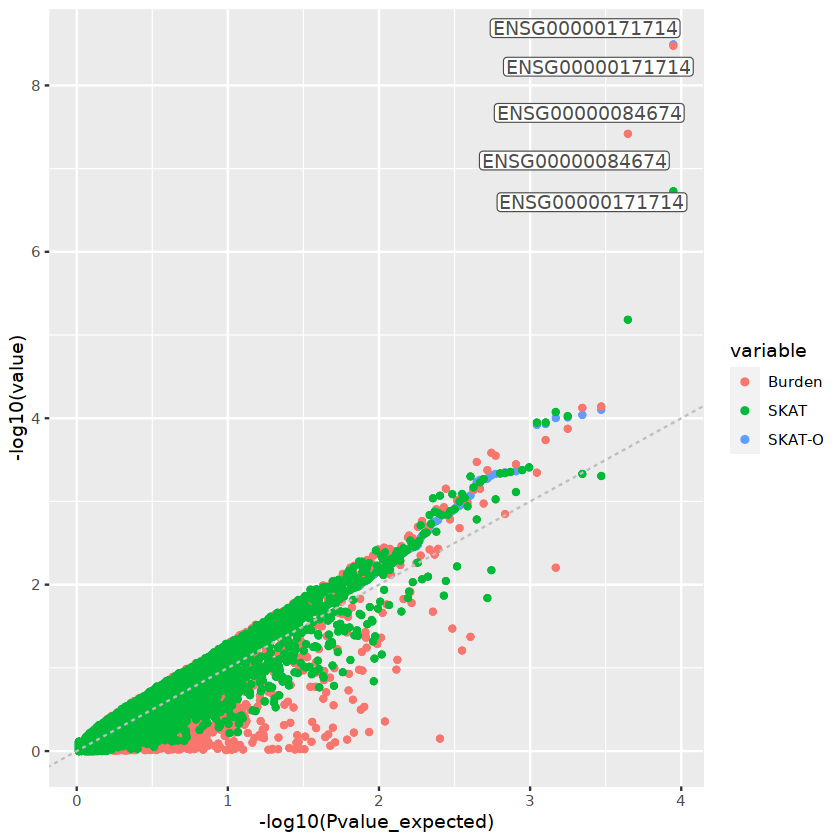

In [68]:

ggplot(lst[[2]][[1]], aes(x=-log10(Pvalue_expected), y=-log10(value), color = variable, label = label)) + 
    geom_point_rast() +
    geom_label_repel(
            box.padding = 0.4, label.padding=0.1, point.padding = 0.2,
            color = 'grey30', segment.color = 'grey50', max.overlaps=Inf,
            size=4, segment.size=0.1, show.legend = FALSE) +
    geom_abline(intercept=0, slope=1, linetype = 'dashed', color = 'grey')

In [12]:



d$p.value.expt <- get_expected_p(d$p.value, na.rm = TRUE)
n <- length(d$p.value)
dt <- data.table(
    ensembl_gene_id = d$MarkerID[order(d$p.value)],
    pvalue.observed = -log10(sort(d$p.value)),
    pvalue.expected = -log10(sort(d$p.value.expt)),
    clower = -log10(qbeta(p = (1 - ribbon_p) / 2, shape2 = n:1, shape1 = 1:n)),
    cupper = -log10(qbeta(p = (1 + ribbon_p) / 2, shape2 = n:1, shape1 = 1:n)),
    seed = gsub('cts_','',str_extract(f, "cts_[0-9]+")),
    parameters = str_extract(f, "h2_.+chr21")
)

Region,Group,max_MAF,Pvalue,Pvalue_Burden,Pvalue_SKAT,BETA_Burden,SE_Burden,MAC,Number_rare,Number_ultra_rare
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>
ENSG00000187634,pLoF,0.001,0.09160552,0.9651496,0.05475976,6.406661e-05,0.0014663116,74,3,6
ENSG00000187634,pLoF,0.010,0.09160552,0.9651496,0.05475976,6.406661e-05,0.0014663116,74,3,6
ENSG00000187634,damaging_missense,0.001,0.30788024,0.3078802,0.30788024,1.292724e-02,0.0126777397,10,0,2
ENSG00000187634,damaging_missense,0.010,0.30788024,0.3078802,0.30788024,1.292724e-02,0.0126777397,10,0,2
ENSG00000187634,synonymous,0.001,0.18369349,0.1635775,0.11032892,-1.369405e-03,0.0009829631,1707,42,53
ENSG00000187634,synonymous,0.010,0.68605201,0.6246382,0.47101505,-2.763846e-04,0.0005648716,5445,48,53
ENSG00000187634,damaging_missense;pLoF,0.001,0.04168696,0.7138033,0.02548688,1.591210e-03,0.0043386435,84,3,8
ENSG00000187634,damaging_missense;pLoF,0.010,0.04168696,0.7138033,0.02548688,1.591210e-03,0.0043386435,84,3,8
ENSG00000187634,synonymous;damaging_missense;pLoF,0.001,0.33993414,0.1977068,0.44010890,-1.236227e-03,0.0009597197,1791,45,61


In [136]:
# simple method to shuffle knockouts
shuffle_knockouts <- function(d){
    d$KO <- rbinom(n=nrow(d), size=1, prob = d$pTKO)
    d$pKO <- ifelse((d$KO == 1 & d$unphased_het == 0), 1,
         ifelse((d$KO == 1 & d$hom_alt_n > 0), 1,
         ifelse((d$phased_het == 1 & d$unphased_het > 0), 1 - 1*(1/2)^d$unphased_het,
         ifelse((d$phased_het == 0 & d$unphased_het > 1), 1 - 2*(1/2)^d$unphased_het, 0))))
    return(d$pKO)
}

# make header of VCF file
make_vcf_dosage_header <- function(chrom){
    vcf_format <- '##fileformat=VCFv4.2'
    vcf_entry <-  '##FORMAT=<ID=DS,Number=1,Type=Float,Description="">'
    vcf_filter <- '##FILTER=<ID=PASS,Description="All filters passed">"'
    vcf_contig <- paste0('##contig=<ID=',chrom,',length=81195210>')
    vcf_out <- paste(vcf_format, vcf_entry, vcf_filter, vcf_contig, sep = '\n')
    return(vcf_out)
}


# make a random string of n characters and numbers
random_string <- function(n){
    return(paste0(sample(c(letters, LETTERS), n, replace = TRUE), collapse = ""))
}

# make vcf-like rows for dosage entries
make_vcf_dosage_rows <- function(chrom, positions, marker, use_random_alleles = TRUE){
    rows <- length(positions)
    refs <- unlist(ifelse(use_random_alleles, list(replicate(rows, random_string(4))), "A0"))
    alts <- unlist(ifelse(use_random_alleles, list(replicate(rows, random_string(4))), "A1"))
    return(data.table(
      "#CHROM" = chrom,
      POS = positions,
      ID = marker,
      REF = refs,
      ALT = alts,
      QUAL = '.',
      FILTER = '.',
      INFO = '.',
      FORMAT = 'DS'
    ))
}

# read real variant data in long format (exported from hail)
# note: need position_last argument, since make_tabix will otherwise complain
# that the positions are not sorted.
format_real_variant_long_to_wide <- function(dt, position_last = 20000){

    stopifnot("s" %in% colnames(dt))
    stopifnot("locus" %in% colnames(dt))
    stopifnot("rsid" %in% colnames(dt))
    stopifnot("alleles" %in% colnames(dt))

    mapping <- dt[,c("locus","alleles","rsid")]
    mapping <- mapping[!duplicated(mapping),]

    # create mapping rows that are to be combined with actual dosages
    alleles <- as.data.frame(do.call(rbind, strsplit(gsub('(")|(\\])|(\\[)','',mapping$alleles), split = ',')))
    colnames(alleles) <- c("REF","ALT")
    mapping <- cbind(mapping, alleles)
    mapping$positions_recoded <- (position_last+1):(position_last+nrow(mapping))
    mapping$positions <- gsub("chr[0-9]+\\:", "",mapping$locus)
    mapping$marker <- paste0(mapping$locus, ":", mapping$REF, ":", mapping$ALT)
    mapping$chroms <- stringr::str_extract(mapping$locus, "chr[0-9]+")
    stopifnot(length(unique(mapping$positions)) == length(mapping$positions)) # can't handle SNPs at same pos
    mapping_rows <- data.table(
        "#CHROM" = mapping$chroms,
          POS = mapping$positions,
          ID = mapping$rsid,
          REF = mapping$REF,
          ALT = mapping$ALT,
          QUAL = '.',
          FILTER = '.',
          INFO = '.',
          FORMAT = 'DS',
          locus = mapping$locus
    )

    # go from long to wide format
    dt <- dt[,c('locus','s','DS')]
    dt <- data.table::dcast(locus~s, data = dt, value.var = "DS")

    # match mapping rows with dt rows
    #new_index <- match(dt$locus, mapping$locus)
    new_index <- match(mapping$locus, dt$locus)
    mapping_rows$locus <- NULL
    #mapping_rows <- mapping_rows[new_index,]
    dt <- dt[new_index,]

    #return(cbind(mapping_rows, dt))
    return(list(rows = mapping_rows, dosages = dt))

}


In [195]:
args <- list(
    input_path = "data/permute/genes/chr12/ukb_eur_wes_200k_pLoF_damaging_missense_chr12_ENSG00000004700.tsv.gz",
    input_path_cond_genotypes = "data/conditional/common/marker_mt/conditional_markers_chrundefined.tsv.gz",
    permutations = 100,
    seed = 42,
    only_non_prob_ko = FALSE,
    remove_invariant_markers = TRUE,
    chrom = "chr12",
    vcf_id = "test"


)

In [197]:
#print(args)
autosomes <- paste0("chr",1:22)
stopifnot(file.exists(args$input_path))
stopifnot(file.exists(args$input_path_cond_genotypes))
stopifnot(!is.na(as.numeric(args$permutations)))
stopifnot(!is.null(args$permutations))
stopifnot(!is.null(args$vcf_id))
stopifnot(args$chrom %in% autosomes)

# seed for reproducibility
seed <- as.numeric(args$seed)
set.seed(seed)

# replicate knockout
n <- as.numeric(args$permutations)
d <- fread(args$input_path)
stopifnot(nrow(d) > 0)
reps <- replicate(n, shuffle_knockouts(d))
rownames(reps) <- d$s
reps <- data.table(t(reps))

# convert to dosage
dosage <- reps * 2

# only keep non-probabilistic knockouts
if (args$only_non_prob_ko) dosage[dosage < 2] <- 0


# load real conditioning variants, i.e. the actual
# dosages/genotypes of the variants that we would like
# to condition on
cond_dt <- fread(args$input_path_cond_genotypes)
cond_dt$chr <- stringr::str_extract(cond_dt$locus, "chr[0-9]+")
cond_dt <- cond_dt[cond_dt$chr %in% args$chrom]
n_real_markers <- length(unique(cond_dt$locus))


# if there are conditioning markers available include them downstream.
if (n_real_markers > 0){

    # ensure that samples are overlapping
    sample_overlap <- unique(intersect(cond_dt$s, d$s))

    # subset dosage matrix (with permuted phased)
    rows <- make_vcf_dosage_rows(args$chrom, 1:n, args$vcf_id)
    dosage <- dosage[,colnames(dosage) %in% sample_overlap, with = FALSE]

    # subset real dosage matrix (with actual calls/DS)
    cond_dt <- cond_dt[cond_dt$s %in% sample_overlap,]
    cond_lst <- format_real_variant_long_to_wide(cond_dt, n)

    # get long format
    cond_rows <- cond_lst$rows
    cond_dosage <- cond_lst$dosage

    # match columns
    cond_dosage$locus <- NULL
    cond_dosage <- cond_dosage[,colnames(dosage), with = FALSE]

    # combine columns and rows. Note: that rbind order
    # matters here when using tabix!
    stopifnot(ncol(rows) == ncol(cond_rows))
    combined_dosages <- rbind(dosage, cond_dosage) 
    combined_meta <- rbind(rows, cond_rows)
    final <- cbind(combined_meta, combined_dosages)
    AC <- rowSums(combined_dosages)

}  else {

    rows <- make_vcf_dosage_rows(args$chrom, 1:n, args$vcf_id)
    rows_dosage <- cbind(rows, dosage)
    final <- rows_dosage
    AC <- rowSums(dosage)
}


if (args$remove_invariant_markers){
    bool_invariant <- AC == 0
    n_invariant <- sum(bool_invariant)
    if (n_invariant > 0){
        final <- final[!bool_invariant,]
        write(paste("Removed", n_invariant, "invariant markers."), stderr())
    }
}





In [192]:
sds <- apply(combined_dosages, 1, sd)

In [193]:
sds

[1] 0.006730631 0.008243283 0.006730631 0.006730631 0.004759288 0.006730631
  [7] 0.006730631 0.006730631 0.004759288 0.006730631 0.006730631 0.006730631
 [13] 0.004759288 0.004759288 0.004759288 0.008243283 0.006730631 0.004759288
 [19] 0.006730631 0.004759288 0.008243283 0.006730631 0.006730631 0.000000000
 [25] 0.000000000 0.004759288 0.006730631 0.004759288 0.006730631 0.000000000
 [31] 0.004759288 0.008243283 0.006730631 0.006730631 0.004759288 0.008243283
 [37] 0.006730631 0.006730631 0.006730631 0.006730631 0.004759288 0.006730631
 [43] 0.006730631 0.008243283 0.008243283 0.006730631 0.006730631 0.004759288
 [49] 0.006730631 0.004759288 0.006730631 0.006730631 0.000000000 0.008243283
 [55] 0.006730631 0.000000000 0.004759288 0.000000000 0.004759288 0.008243283
 [61] 0.006730631 0.006730631 0.006730631 0.004759288 0.000000000 0.004759288
 [67] 0.008243283 0.006730631 0.004759288 0.000000000 0.006730631 0.004759288
 [73] 0.006730631 0.004759288 0.006730631 0.004759288 0.000000000 0.000000000
 [79] 0.006730631 0.006730631 0.004759288 0.004759288 0.000000000 0.004759288
 [85] 0.004759288 0.006730631 0.008243283 0.004759288 0.006730631 0.006730631
 [91] 0.004759288 0.004759288 0.000000000 0.000000000 0.004759288 0.000000000
 [97] 0.004759288 0.004759288 0.004759288 0.004759288 0.699859458

In [2]:
library(ggplot2)
library(dplyr)
library(ggsci)
library(ggrastr)
library(ggrepel)
library(data.table)
library(latex2exp)

chr_lengths_38 <- c(248956422, 242193529, 198295559,190214555,181538259,170805979,159345973,
    145138636,138394717,133797422,135086622,133275309,114364328,107043718,101991189,90338345,
    83257441,80373285,58617616,64444167,46709983,50818468,156040895)

chr_lengths_37 <- c(249250621, 243199373,198022430,191154276,180915260,171115067,159138663,
    146364022,141213431,135534747,135006516,133851895,115169878,107349540,102531392,90354753,
    81195210,78077248,59128983,63025520,48129895,51304566,155270560)

create_pretty_forest <- function(df, title, save_figure=FALSE, file='file_out',
    width=160, height=90, scaling=1, y_label='', pass_order=NULL, print_p=TRUE,
    horizontal=TRUE, hline_at=0, ggplot_theme=theme_classic)
{
    if (!is.null(pass_order)) {
        df$label <- factor(df$label, levels = df$label[pass_order])
    }

    p <- ggplot(data=df, aes(x=label, y=mean, ymin=lower, ymax=upper)) +
        geom_pointrange() + 
        geom_hline(yintercept=hline_at, lty=2)

    if (horizontal==TRUE) p <- p + coord_flip()

    p <- p + labs(title=title, y=y_label, x='') +
        ggplot_theme()

    if (horizontal == TRUE) {
        p <- p + geom_text(aes(y=mean, label=p_vals), vjust=-1)
    } else {
        p <- p + geom_text(aes(y=mean, label=p_vals), hjust=-0.2)
    }

    if (print_p)  print(p)

    if (save_figure) {
        ggsave(paste0(file, '.jpg'), p, width=width*scaling, height=height*scaling, units='mm', dpi=500)
        ggsave(paste0(file, '.pdf'), p, width=width*scaling, height=height*scaling, units='mm')
    }
    
    return(p)
}

create_pretty_hist <- function(df, aest, x_label, threshold=NULL, threshold_max=NULL,
    file='file_out', title='', binwidth=0.002, width=160, height=90, scaling=1,
    save_figure=FALSE, xlim=NULL, key_label='', print_p=TRUE, title.hjust=0.5, ggplot_theme=theme_classic)
{
    p <- ggplot(df, aest)
    geom_histogram(binwidth=binwidth, fill='#aec7e8', color='#1f77b4')
    ylim <- ggplot_build(p)$layout$panel_ranges[[1]]$y.range
    p <- ggplot(df, aest)

    if (is.null(aest$fill)) {
        p <- p + geom_histogram(binwidth=binwidth, fill='#aec7e8', color='#1f77b4')
    } else {
        p <- p + geom_histogram(binwidth=binwidth, color='grey50')
    }

    if (!is.null(xlim)) {
        p <- p + coord_cartesian(xlim=xlim)
    } 

    p <- p + labs(x=x_label, y='Count', title=title, fill=key_label) +
    scale_x_continuous(breaks=scales::pretty_breaks(n=10)) +
    scale_y_continuous(label=scales::comma, breaks=scales::pretty_breaks(n=10)) +
    ggplot_theme() +
    theme(axis.title.x = element_text(margin=ggplot2::margin(t=10)),
    axis.title.y = element_text(margin=ggplot2::margin(r=10)),
    plot.title = element_text(hjust=title.hjust))

    if (!is.null(threshold)) p <- p + geom_vline(xintercept=threshold, linetype='dashed')
    if (!is.null(threshold_max)) p <- p + geom_vline(xintercept=threshold_max, linetype='dashed')

    
    if (print_p) print(p)

    if (save_figure) {
        ggsave(paste0(file, '.jpg'), p, width=width*scaling, height=height*scaling, units='mm', dpi=500)
        ggsave(paste0(file, '.pdf'), p, width=width*scaling, height=height*scaling, units='mm')
    }
    
    return(p)
}

create_pretty_density <- function(df, aest, x_label, threshold=NULL, threshold_max=NULL,
    file='file_out', title='', binwidth=0.002, width=160, height=90, scaling=1,
    save_figure=FALSE, xlim=NULL, key_label='', print_p=FALSE, title.hjust=0.5,
    ggplot_theme=theme_classic)
{
    p <- ggplot(df, aest)
    ylim <- ggplot_build(p)$layout$panel_ranges[[1]]$y.range
    p <- ggplot(df, aest)

    if (is.null(aest$fill)) {
        p <- p + geom_density(fill='#aec7e8', color='#1f77b4')
    } else {
        p <- p + geom_density(color='grey50')
    }

    if (!is.null(xlim)) {
        p <- p + coord_cartesian(xlim=xlim)
    } 

    p <- p + labs(x=x_label, y='Count', title=title, fill=key_label) +
    scale_x_continuous(breaks=scales::pretty_breaks(n=10)) +
    scale_y_continuous(label=scales::comma, breaks=scales::pretty_breaks(n=10)) +
    ggplot_theme() +
    theme(axis.title.x = element_text(margin=ggplot2::margin(t=10)),
    axis.title.y = element_text(margin=ggplot2::margin(r=10)),
    plot.title = element_text(hjust=title.hjust))

    if (!is.null(threshold)) {
        p <- p + geom_vline(xintercept=threshold, linetype='dashed') #+
        # annotate('text', label=paste0(x_label, ' = ', threshold), x=threshold, y=0.8*ylim[2], angle=90, vjust=-1)
    }
    if (!is.null(threshold_max)) {
        p <- p + geom_vline(xintercept=threshold_max, linetype='dashed') #+
        # annotate('text', label=paste0(x_label, ' = ', threshold_max), x=threshold_max, y=0.8*ylim[2], angle=90, vjust=2)
    }

    if (print_p) print(p)

    if (save_figure) {
        ggsave(paste0(file, '.jpg'), p, width=width*scaling, height=height*scaling, units='mm', dpi=500)
        ggsave(paste0(file, '.pdf'), p, width=width*scaling, height=height*scaling, units='mm')
    }
    
    return(p)
}

create_pretty_boxplots <- function(df, aes, aes_col, threshold=NULL,
    threshold_max=NULL, file='file_out', title='', x_label='', y_label='',
    key_label='', xlim=NULL, legend=FALSE, save_figure=FALSE, 
    width=160, height=90, scaling=1, facet=FALSE, facet_grid=NULL, jitter_size=0.5,
    outlier.shape=NA, n_ticks=10, print_p=FALSE, alpha=0.6, title.hjust=0.5, ggplot_theme=theme_classic)
{
    p = ggplot(df, aes) +
        geom_boxplot(outlier.shape=outlier.shape, coef=0, color='grey50', fill='grey95', show.legend=FALSE) + 
        geom_jitter_rast(width=0.2, height=0, size=jitter_size, aes_col, show.legend=legend, alpha=alpha, stroke=0.05, raster.dpi=500) + 
        coord_flip(ylim=xlim) +
        labs(title=title, x=y_label, y=x_label, color=key_label) + 
        scale_color_d3('category20') +
        scale_y_continuous(breaks = scales::pretty_breaks(n=n_ticks)) +
        guides(color = guide_legend(override.aes = list(size=2))) +
        ggplot_theme() +
        theme(axis.title.x = element_text(margin = ggplot2::margin(t=10)),
              plot.title = element_text(hjust=title.hjust))

    if (!is.null(threshold)) {
        p <- p + geom_hline(yintercept=threshold, linetype='dashed')
    }
    if (!is.null(threshold_max)) {
        p <- p + geom_hline(yintercept=threshold_max, linetype='dashed')
    }
    if (facet){
        p <- p + facet_grid
    }

    if (print_p) print(p)

    if (save_figure) {
        ggsave(paste0(file, '.jpg'), p, width=width*scaling, height=height*scaling, units='mm', dpi=500)
        ggsave(paste0(file, '.pdf'), p, width=width*scaling, height=height*scaling, units='mm')
    }
    return(p)
}

create_pretty_cumulative <- function(df, aes, x_label, threshold, threshold_max=NULL,
    file='file_out', title='', width=160, height=90, scaling=1, save_figure=FALSE,
    xlim=c(0,1), key_label='', print_p=FALSE, title.hjust=0.5, ggplot_theme=theme_classic)
{
    # These next ones are cdfs.
    p = ggplot(df, aes) + 
        stat_ecdf(geom='step', pad=FALSE) +
        geom_vline(xintercept=threshold, linetype='dashed') +
        coord_cartesian(xlim=xlim) +
        labs(x=x_label, y='Cumulative Proportion', title=title, color=key_label) +
        scale_color_d3('category10') +
        scale_x_continuous(breaks=scales::pretty_breaks(n=10)) +
        scale_y_continuous(breaks=scales::pretty_breaks(n=10)) +
        ggplot_theme() +
        theme(axis.title.x = element_text(margin=ggplot2::margin(t=10)),
              axis.title.y = element_text(margin=ggplot2::margin(r=10)),
              plot.title = element_text(hjust=title.hjust))

    # p <- p + annotate('text', label=paste0(x_label, ' = ', threshold), x=threshold, y=mean(ylim), angle=90, vjust=-1)
    # ylim <- ggplot_build(p)$panel$ranges[[1]]$y.range
    # print(ylim)

    if (!is.null(threshold_max)) {
        p <- p + geom_vline(xintercept=threshold_max, linetype='dashed')# +
        # annotate('text', label=paste0(x_label, ' = ', threshold_max), x=threshold_max, y=mean(ylim), angle=90, vjust=2)
    }
    if (print_p) print(p)

    if (save_figure) {
        ggsave(paste0(file, '.jpg'), p, width=width*scaling, height=height*scaling, units='mm', dpi=500)
        ggsave(paste0(file, '.pdf'), p, width=width*scaling, height=height*scaling, units='mm')
    }
    return(p)
}

create_pretty_scatter <- function(dt, aes, file='file_out', save_figure=FALSE, 
    key_label='', title='', limits=NULL, width=160, height=90, presentation=FALSE,
    add_final_layer=FALSE, final_layer=NULL, n_x_ticks=10, n_y_ticks=10, x_label=NULL,
    y_label=NULL, print_p=FALSE, gradient=FALSE, midpoint=0, gradient_title="", title.hjust=0.5,
    legend_max_min=NULL, n_legend_step=4, xlim=NULL, ylim=NULL, ggplot_theme=theme_classic, alpha=0.6, size=1,
    include_qq_ribbon=FALSE, aes_ribbon=NULL, ribbon_p=0.95)
{
    p <- ggplot(dt, aes)
    print(dt)
    if (include_qq_ribbon) {
        p <- p + geom_ribbon(aes_ribbon, fill="grey80", color="grey80")
    }
    
    if ("size" %in% names(aes)) {
        p <- p + geom_point_rast(alpha=alpha, raster.dpi=500)
    } else {
        p <- p + geom_point_rast(alpha=alpha, size=size, raster.dpi=500)
    }
    p <- p +
        scale_color_d3('category20', limits=limits) +
        labs(title=title, color=paste0(key_label)) +
        scale_x_continuous(breaks=scales::pretty_breaks(n=n_x_ticks)) +
        scale_y_continuous(breaks=scales::pretty_breaks(n=n_y_ticks)) +
        ggplot_theme() +
        theme(axis.title.x = element_text(margin=ggplot2::margin(t=10)),
              axis.title.y = element_text(margin=ggplot2::margin(r=10)),
              plot.title = element_text(hjust=title.hjust))

    if (add_final_layer) {
        cat("Adding final layer...\n")
        p <- p + guides(fill=FALSE) + geom_point_rast(mapping=aes, data=final_layer, raster.dpi=500) + scale_color_d3('category20')
    }

    if (gradient) {
        print(gradient_title)
        if(!is.null(legend_max_min)) {
            p <- p + scale_color_gradient2(
                low="blue", high="red", mid='grey50', midpoint=midpoint,
                name=gradient_title,
                breaks=seq(legend_max_min[1], legend_max_min[2], (legend_max_min[2]-legend_max_min[1])/n_legend_step))
        } else {
            p <- p + scale_color_gradient2(
                low="blue", high="red", mid='grey50', midpoint=midpoint,
                name=gradient_title)
        }
    }
    
    cat("Adding axis labels...\n")
    if (!is.null(x_label)) p <- p + labs(x=x_label)
    if (!is.null(y_label)) p <- p + labs(y=y_label)
    if (!is.null(xlim)) p <- p + xlim(xlim[1], xlim[2])
    if (!is.null(ylim)) p <- p + ylim(ylim[1], ylim[2])

    cat("Saving figure...\n")
    if (print_p) print(p)

    if (save_figure) {
        
        if (presentation == TRUE) {
            width <- 160
            height <- 90
            ggsave(paste0(file, '.jpg'), p, width=width, height=height, units='mm', dpi=500)
        } else {
            ggsave(paste0(file, '.jpg'), p, width=width, height=height, units='mm', dpi=500)
            ggsave(paste0(file, '.pdf'), p, width=width, height=height, units='mm')
        }
    
    }

    return(p)
}

create_pretty_qq_plot <- function(dt, aes, file='file_out', save_figure=FALSE,
    plot_title='', limits=NULL, width=110, height=100, n_x_ticks=10, n_y_ticks=10,
    x_label=TeX("$-\\log_{10}(\\mathit{p}_{permutation})$"), 
    y_label=TeX("$-\\log_{10}(\\mathit{p}_{observed})$"),
    n_to_include=NULL, cex_labels=1, print_p=TRUE, gradient=FALSE,
    gradient_title="", title.hjust=0.5, legend_max_min=NULL, n_legend_step=4,
    xlim=NULL, ylim=NULL, y_x_col="grey40", ggplot_theme=theme_classic, alpha=0.6,
    include_qq_ribbon=TRUE, aes_ribbon=NULL, ribbon_p=0.95, key_cols=c("pval"))
{
    cat("Creating scatter-plot...\n")
    dt <- data.table(dt)
    setkeyv(dt, cols=key_cols)
    print(dt)
    p <- create_pretty_scatter(dt, aes, file=file, save_figure=FALSE,
        title=plot_title, limits=limits,
        width=width, height=height, n_x_ticks=n_x_ticks, n_y_ticks=n_y_ticks,
        x_label=x_label, y_label=y_label, gradient=gradient, gradient_title=gradient_title,
        title.hjust=title.hjust, legend_max_min=legend_max_min, n_legend_step=n_legend_step,
        xlim=xlim, ylim=ylim, ggplot_theme=ggplot_theme, alpha=alpha,
        include_qq_ribbon=include_qq_ribbon, aes_ribbon=aes_ribbon, ribbon_p=ribbon_p)

    cat("Adding y=x line...\n")
    p <- p + geom_abline(intercept=0, slope=1, color=y_x_col) #+ coord_fixed()

    if (!is.null(n_to_include)) {
        cat("Adding labels...\n")
        p <- p + geom_label_repel(data=dt[(nrow(dt)-n_to_include+1):nrow(dt), ],
            aes(label=labels), box.padding = 0.4, label.padding=0.1, point.padding = 0.2,
            color = 'grey30', segment.color = 'grey50', max.overlaps=Inf,
            size=cex_labels, segment.size=0.1, show.legend = FALSE)
    }

    if (save_figure) {
        ggsave(paste0(file, '.jpg'), p, width=width, height=height, units='mm', dpi=500)
        ggsave(paste0(file, '.pdf'), p, width=width, height=height, units='mm')
    }
    
    cat("Created scatter-plot...\n")
    if (print_p) print(p)

    return(p)
}

create_pretty_pointrange <- function(dt, y, ymin, ymax, colors="phenotype",
    break_on="phenotype", x_labels="phenotype", threshold=NULL, file='file_out',
    title='', width=165, height=110, save_figure=FALSE, xlim=NULL, key_label='',
    print_p=FALSE, title.hjust=0.5, split_on=NULL, spacing=7, x_label="", y_label="",
    title_size=NULL, manual_colours=NULL, colour_levels=NULL, break_on_levels=NULL,
    ggplot_theme=theme_classic, ylim=NULL)
{   
    if(!is.null(colour_levels)) {
        dt[[colors]] <- factor(dt[[colors]], levels=colour_levels)
    } else {
        dt[[colors]] <- factor(dt[[colors]])
    }

    if(!is.null(break_on_levels)) {
        dt[[break_on]] <- factor(dt[[break_on]], levels=break_on_levels)
    } else {
        dt[[break_on]] <- factor(dt[[break_on]])
    }

    dt <- dt %>% arrange(dt[[break_on]], dt[[colors]])

    dt1 <- cbind(dt, aux=rep(1,length(dt[,1]))) 
    dt1 <- within(dt1, {aux = unlist(by(aux, dt1[[break_on]], cumsum))})
    dt1$aux <- dt1$aux + as.numeric(factor(dt1[[break_on]])) * (length(unique(factor(dt1[[break_on]]))) + spacing)

    print(head(dt1))

    define_breaks <- function(dt, split_on) {
        breaks <- c()
        for (split in unique(dt[[split_on]])) {
            breaks <- c(breaks, mean(unlist(dt %>% filter(dt[[split_on]] == split) %>% select(aux))))
        }
        return(breaks)
    }

    p <- ggplot(dt1, aes(x=dt1$aux, y = dt1[[y]], ymin = dt1[[ymin]], ymax = dt1[[ymax]])) +
    geom_pointrange(aes(color = dt1[[colors]]), size = 0.5) + 
    scale_x_continuous("", breaks=define_breaks(dt1, break_on), labels=unique(dt1[[break_on]])) +
    labs(x=x_label, y=y_label, title=title, color=key_label)

    if (!is.null(manual_colours)) {
        p <- p + scale_color_manual(labels=colour_levels, values=manual_colours)
    } else {
        p <- p + scale_color_d3('category10')
    }
    p <- p +
    ggplot_theme() +
    theme(axis.title.x = element_text(margin=ggplot2::margin(t=10)),
          axis.title.y = element_text(margin=ggplot2::margin(r=10)),
          plot.title = element_text(hjust=title.hjust))

    if(!is.null(threshold)) {
        p <- p + geom_hline(yintercept=threshold, linetype='dashed', col="grey40")
    }

    if (!is.null(title_size)) 
        p <- p + theme(plot.title = element_text(size=title_size))

    if (!is.null(ylim)) p <- p + ylim(ylim[1], ylim[2])

    if(print_p) print(p)

    if (save_figure) {
        ggsave(paste0(file, '.jpg'), p, width=width, height=height, units='mm', dpi=500)
        ggsave(paste0(file, '.pdf'), p, width=width, height=height, units='mm')
    }
    return(p)
}

get_start_and_end <- function(chr_lengths) {
    start <- rep(0, length(chr_lengths))
    start[1] <- 1
    end <- rep(0, length(chr_lengths))
    end[1] <- chr_lengths[1]
    for(chr in 2:length(chr_lengths)) {
        start[chr] <- start[chr-1] + chr_lengths[chr-1]
        end[chr] <- end[chr-1] + chr_lengths[chr]
    }
    return(list(start=start, end=end))
}

make_manhattan_plot = function(contigs, positions, pvals, log_OR=NULL, labels=NULL, size_by_p=FALSE, buffer=100000000, title='', threshold=5, chr_lengths=chr_lengths_38,
  colour_aes=NULL, log_p_vals=FALSE, significance_T=5e-8, ggplot_theme=theme_bw, two_tone=TRUE, by_OR=FALSE, colour_1='#2b59a1', colour_2='#5fb756',
  save_figure=FALSE, file='file_out', scaling=1, width=230, height=100, title_size=NULL, minus_log_p_max=NULL, print_p=FALSE)
{  
    contigs_ <- c(1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23)
    start_end <- get_start_and_end(chr_lengths)
    dt_contigs <- data.frame(contig=contigs_, start=start_end$start, end=start_end$end) %>%
    mutate(middle = floor(start + (end-start)/2),
           length = (end-start)) %>%
    mutate(shifted_position=middle + (contig - 1) * buffer)

    dt_plot <- data.frame(contig=contigs, position=as.integer(positions), pval=as.numeric(pvals), labels=labels) %>%
    mutate(x = dt_contigs[gsub('X', '23', contig), 'start'] + position + (as.integer(gsub('X', '23', contig))-1)*buffer)

    # Include two tone chromosome plotting
    if (two_tone) {
        dt_plot <- dt_plot %>% mutate(colour=ifelse((as.integer(gsub('X', '23', contig)) %% 2) == 0, colour_1, colour_2))
    } else {
        dt_plot <- dt_plot %>% mutate(colour=colour_1) 
    }

    if (by_OR & !is.null(log_OR)) {
        dt_plot$log_OR <- log_OR
        dt_plot <- dt_plot %>% mutate(colour = case_when(
            dt_plot$log_OR < -1 ~ "blue3",
            ((dt_plot$log_OR > -1) & (dt_plot$log_OR <= 0)) ~ "cornflowerblue",
            ((dt_plot$log_OR > 0) & (dt_plot$log_OR <= 1)) ~ "indianred3",
            dt_plot$log_OR > 1 ~ "red",
            TRUE ~ "grey40")
        )
        dt_plot$colour <- factor(dt_plot$colour, levels = c("red", "indianred3", "cornflowerblue", "blue3"))
    }

    # Were log p-values passed?
    if(!log_p_vals) {
        dt_plot <- dt_plot %>% mutate(y = -log10(pval)) %>% select(x, y, colour, labels)
    } else {
        dt_plot <- dt_plot %>% mutate(y= pval) %>% select(x, y, colour, labels)
    }

    if (size_by_p) {
        dt_plot <- dt_plot %>% mutate(size = case_when(
            dt_plot$y > 3 ~ 20,
            ((dt_plot$y > -log10(0.05)) & (dt_plot$y <= 3)) ~ 5,
            TRUE ~ 0.5)
        )
    }

    if (size_by_p) {
        p <- ggplot(dt_plot, aes(x=x,y=y,label=labels, col=colour, size=size)) + geom_point_rast()
    } else {
        p <- ggplot(dt_plot, aes(x=x,y=y,label=labels, col=colour)) + geom_point_rast(size=0.5)
    }

    p <- p + geom_hline(yintercept=-log10(significance_T), color='#E15759', linetype='dashed') +
        scale_x_continuous(breaks=dt_contigs$shifted_position, labels=gsub(23, 'X', dt_contigs$contig)) +
        scale_y_continuous(breaks=scales::pretty_breaks(n=10)) +
        labs(x='Chromosome', y=TeX("$-\\log_{10}(\\mathit{p})$"), title=title) + ggplot_theme()

    if ((by_OR == FALSE) & (size_by_p==FALSE)) {
        p <- p + theme(legend.position = "none")
    }

    if (two_tone) { p <- p + scale_color_manual(values=c(colour_1,colour_2)) }
    if (by_OR) { 
        p <- p + scale_colour_manual(name="Odds ratio",
            values = levels(dt_plot$colour), labels=c("> 10", "1 - 10", "0.1 - 1", "< 0.1"))
    }

    if (!is.null(labels))
        p <- p + geom_label_repel(
            data=subset(dt_plot, y > threshold), size = 5,
            aes(label=labels), color='grey30', box.padding = 0.35, point.padding = 0.5, segment.color = 'grey50')

    if (!is.null(title_size)) 
        p <- p + theme(plot.title = element_text(size=title_size))

    if (!is.null(minus_log_p_max))
        p <- p + ylim(0, minus_log_p_max)

    if (save_figure) {
        ggsave(paste0(file, '.jpg'), p, width=width*scaling, height=height*scaling, units='mm')
        ggsave(paste0(file, '.pdf'), p, width=width*scaling, height=height*scaling, units='mm')
    }

    if (print_p) { print(p) }

    return(list(p=p, dt=dt_plot))
}

In [3]:
library(ggplot2)
library(dplyr)
library(ggsci)
library(ggrastr)
library(ggrepel)
library(data.table)
library(latex2exp)

In [4]:
read_and_create_qq <- function(
	phenotype = "coronary_artery_disease",
	minMAFs=c("0"),#, "0", "0.01"),
	maxMAFs=c("0.01"),#, "0.5", "0.5"),
	variant_classes=c(
		"pLoF",
		"damaging_missense",
		"other_missense",
		"synonymous"), 
	outdir=""
	)
{
	if(length(minMAFs) != length(maxMAFs)) { stop("minMAFs and maxMAFs must be the same length") }
	
	# Create the QQ plots
	pdf(file=paste0(outdir, phenotype, "_qq.pdf"), width=4.5, height=3.5)
	for (i in 1:length(minMAFs)) {
		for (variant_class in variant_classes) {
			variant_class_plot <- gsub("\\|", ", ", variant_class)
			variant_class_plot <- gsub("_", " ", variant_class_plot)
			variant_class_filename <- gsub("\\|", "_", variant_class)
			dt <- list()
			#for (chr in seq(1,22)) {
			#	cat(paste0("chromosome ", chr, "..."))
			#	dt[[chr]] <- fread(get_SAIGE_output_path(phenotype, chr, minMAFs[i], maxMAFs[i], variant_class_filename))
			#}
			cols <- c("Gene", "Pvalue", "Pvalue_Burden", "Pvalue_SKAT")
			dt <- rbindlist(dt)[, ..cols]
			dt[, Burden := ifelse(is.na(Pvalue_Burden), -log10(Pvalue), -log10(Pvalue_Burden))]
			dt[, SKAT := ifelse(is.na(Pvalue_SKAT), -log10(Pvalue), -log10(Pvalue_SKAT))]
			dt[, `SKAT-O` := -log10(Pvalue)]
			dt[, GeneID := gsub("_.*", "", Gene)]
			dt[, GeneName := gsub("^[^_]*_([^_]*)_.*", "\\1", Gene)]
			ribbon_p <- 0.95
			dt <- melt(dt, id.vars=c("GeneID", "GeneName"), measure.vars=c("Burden", "SKAT", "SKAT-O"), variable.name = "test" , value.name="Pvalue")
			dt <- data.table(
				dt %>% arrange(test, desc(Pvalue)) %>% select(-test),
				dt %>% group_by(test) %>% arrange(desc(Pvalue)) %>% 
					summarize(
						Pvalue_expected = -log10(seq(1, n())/(n() + 1)),
						clower = -log10(qbeta(p = (1 - ribbon_p) / 2, shape2 = n():1, shape1 = 1:n())),
						cupper = -log10(qbeta(p = (1 + ribbon_p) / 2, shape2 = n():1, shape1 = 1:n()))
						)
					)
			cat(paste("\nPhenotype:", phenotype, "\n"))
			create_pretty_qq_plot(
				plot_title=paste0(
					gsub("_", " ", paste0(toupper(substring(phenotype, 1,1)), substring(phenotype, 2))), "\n",
					"MAF: ", minMAFs[i], "-", maxMAFs[i], "\n",
					variant_class_plot
					),
				cex_labels=2,
				dt %>% mutate(labels=GeneName), aes(x=Pvalue_expected, y=Pvalue, color=test),
				save_figure=FALSE, n_to_include=10,
				x_label=TeX("$-\\log_{10}(\\mathit{p}_{expected})$"), 
				y_label=TeX("$-\\log_{10}(\\mathit{p}_{observed})$"),
				key_cols=c("test", "Pvalue"),
				aes_ribbon = aes(ymin=clower, ymax=cupper),
				width=170, height=120
			)
		}
	}
	dev.off()
}

In [5]:
max_MAFs=c("0.01")
variant_classes=c("pLoF","damaging_missense","synonymous")

In [61]:
for (i in 1:length(max_MAFs)) {
    for (variant_class in variant_classes) {
        
        dt <- fread(files[1])
        dt <- dt[dt$Group %in% variant_classes, ]
        dt <- dt[dt$max_MAF %in% max_MAFs[i], ]
        cols <- c("Region", "Pvalue", "Pvalue_Burden", "Pvalue_SKAT")
        dt[, Burden := ifelse(is.na(Pvalue_Burden), -log10(Pvalue), -log10(Pvalue_Burden))]
        dt[, SKAT := ifelse(is.na(Pvalue_SKAT), -log10(Pvalue), -log10(Pvalue_SKAT))]
        dt[, `SKAT-O` := -log10(Pvalue)]
        ribbon_p <- 0.95
        dt <- melt(dt, id.vars=c("Region"), measure.vars=c("Burden", "SKAT", "SKAT-O"), variable.name = "test" , value.name="Pvalue")
        dt <- data.table(
            dt %>% arrange(test, desc(Pvalue)) %>% select(-test),
               %>% group_by(test) %>% arrange(desc(Pvalue)) %>% 
                    summarize(
                        Pvalue_expected = -log10(seq(1, n())/(n() + 1)),
                        clower = -log10(qbeta(p = (1 - ribbon_p) / 2, shape2 = n():1, shape1 = 1:n())),
                        cupper = -log10(qbeta(p = (1 + ribbon_p) / 2, shape2 = n():1, shape1 = 1:n()))
                        )
                    )
        
    }
}


ERROR: Error in parse(text = x, srcfile = src): <text>:15:16: unexpected SPECIAL
14:             dt %>% arrange(test, desc(Pvalue)) %>% select(-test),
15:                %>%
                   ^


In [5]:
library(data.table)

In [6]:
d <- fread("data/phenotypes/filtered_covar_phenotypes_cts.tsv.gz")

In [7]:
colnames(d)

[1] "eid"                                          
  [2] "Alanine_aminotransferase"                     
  [3] "Albumin"                                      
  [4] "Alkaline_Phosphatase"                         
  [5] "Apolipoprotein_A"                             
  [6] "Apolipoprotein_B"                             
  [7] "Aspartate_aminotransferase"                   
  [8] "C_reactive_Protein"                           
  [9] "Calcium"                                      
 [10] "Cholesterol"                                  
 [11] "Creatinine_Serum"                             
 [12] "Creatinine_Urine"                             
 [13] "Cystatin_C_Serum"                             
 [14] "Direct_Bilirubin"                             
 [15] "Gamma_glutamyltransferase"                    
 [16] "Glucose"                                      
 [17] "HbA1c"                                        
 [18] "HDL_Cholesterol"                              
 [19] "IGF_1"                                        
 [20] "Lipoprotein_A"                                
 [21] "Microalbumin_Urine"                           
 [22] "Oestradiol"                                   
 [23] "Phosphate"                                    
 [24] "Potassium_Urine"                              
 [25] "Rheumatoid_factor"                            
 [26] "SHBG"                                         
 [27] "Sodium_Urine"                                 
 [28] "Testosterone"                                 
 [29] "Total_Bilirubin"                              
 [30] "Total_Protein"                                
 [31] "Triglyceride"                                 
 [32] "Urate"                                        
 [33] "Urea"                                         
 [34] "Vitamin_D"                                    
 [35] "Alanine_aminotransferase_residual"            
 [36] "Albumin_residual"                             
 [37] "Alkaline_Phosphatase_residual"                
 [38] "Apolipoprotein_A_residual"                    
 [39] "Apolipoprotein_B_residual"                    
 [40] "Aspartate_aminotransferase_residual"          
 [41] "C_reactive_Protein_residual"                  
 [42] "Calcium_residual"                             
 [43] "Cholesterol_residual"                         
 [44] "Creatinine_Serum_residual"                    
 [45] "Creatinine_Urine_residual"                    
 [46] "Cystatin_C_Serum_residual"                    
 [47] "Direct_Bilirubin_residual"                    
 [48] "Gamma_glutamyltransferase_residual"           
 [49] "Glucose_residual"                             
 [50] "HbA1c_residual"                               
 [51] "HDL_Cholesterol_residual"                     
 [52] "IGF_1_residual"                               
 [53] "Lipoprotein_A_residual"                       
 [54] "Microalbumin_Urine_residual"                  
 [55] "Oestradiol_residual"                          
 [56] "Phosphate_residual"                           
 [57] "Potassium_Urine_residual"                     
 [58] "Rheumatoid_factor_residual"                   
 [59] "SHBG_residual"                                
 [60] "Sodium_Urine_residual"                        
 [61] "Testosterone_residual"                        
 [62] "Total_Bilirubin_residual"                     
 [63] "Total_Protein_residual"                       
 [64] "Triglyceride_residual"                        
 [65] "Urate_residual"                               
 [66] "Urea_residual"                                
 [67] "Vitamin_D_residual"                           
 [68] "Alanine_aminotransferase_M_residual"          
 [69] "Albumin_M_residual"                           
 [70] "Alkaline_Phosphatase_M_residual"              
 [71] "Apolipoprotein_A_M_residual"                  
 [72] "Apolipoprotein_B_M_residual"                  
 [73] "Aspartate_aminotransferase_M_residual"        
 [74] "C_reactive_Protein_M_residual"                
 [75] 

In [8]:
head(d$sex)

[1] 0 0 1 1 0 1

In [23]:
d$sex_age2 <- d$age2 * ifelse(d$sex == 0, 1, -1)
d$sex_age3 <- d$age3 * ifelse(d$sex == 0, 1, -1)

In [24]:
PCs <- paste0(paste0("PC",1:10), collapse = '+')

[1] "Apolipoprotein_B~ukbb.centre+PC1+PC2+PC3+PC4+PC5+PC6+PC7+PC8+PC9+PC10"


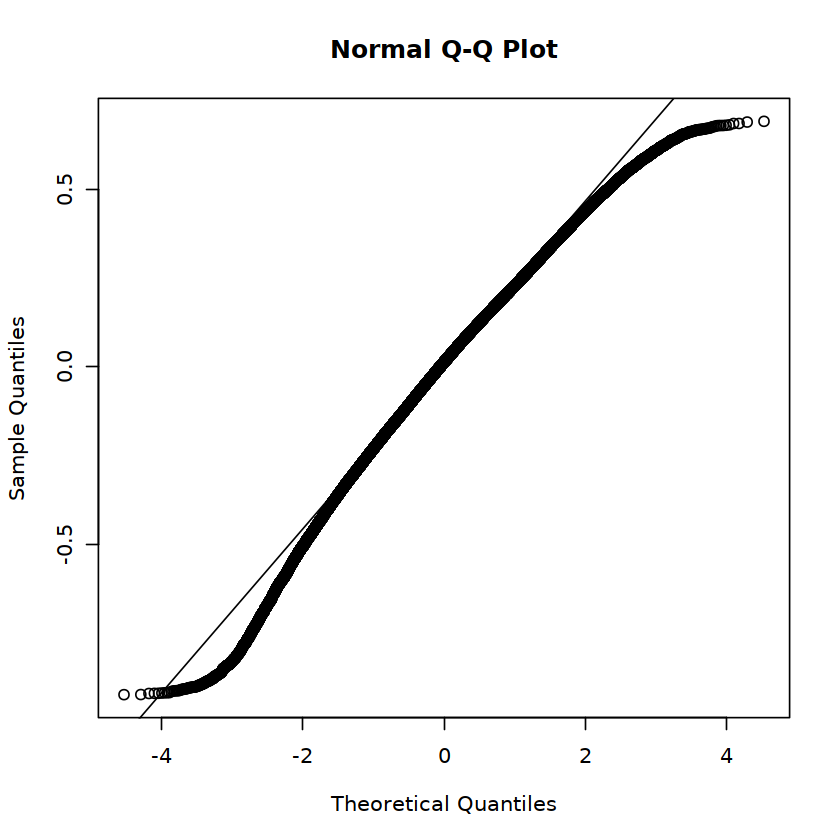

In [37]:
#f <- paste0("Apolipoprotein_B~ukbb.centre+sex+sex:age+sex:age2+sex:age3+age+",PCs)
#f <- paste0("Apolipoprotein_B~ukbb.centre+sex+age+sex_age+sex_age2+sex_age3+",PCs)
f <- paste0("Apolipoprotein_B~ukbb.centre+",PCs)
fit <- lm(as.formula(f), data = d)
r <- residuals(fit)
print(f)
qqnorm(r)
qqline(r)

[1] "Apolipoprotein_B~ukbb.centre+sex+sex:age+sex:age2+sex:age3+age+PC1+PC2+PC3+PC4+PC5+PC6+PC7+PC8+PC9+PC10"


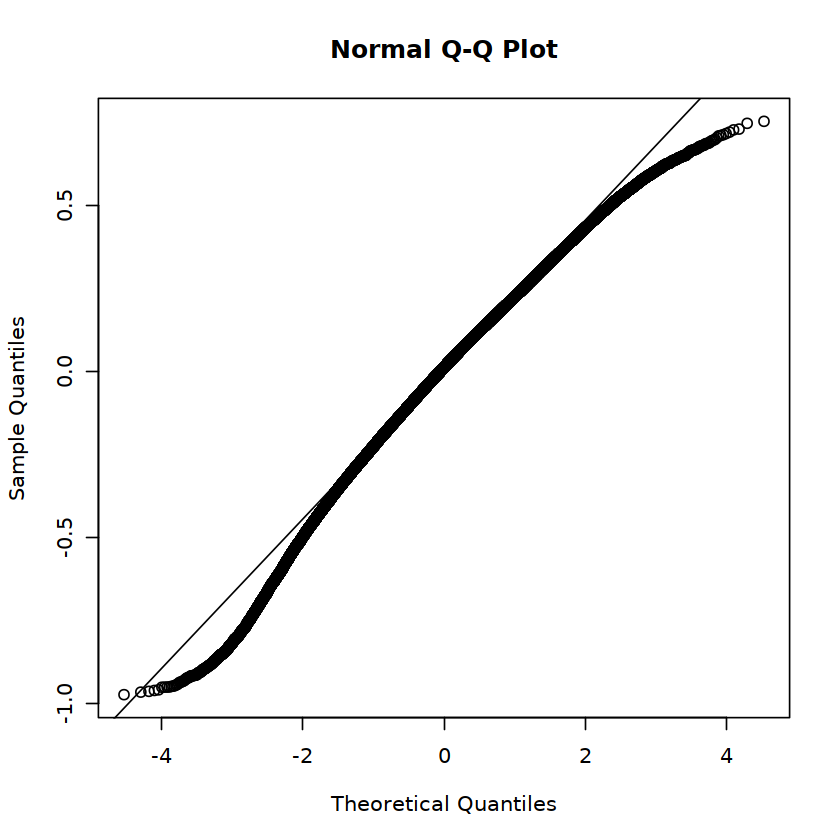

In [38]:
f <- paste0("Apolipoprotein_B~ukbb.centre+sex+sex:age+sex:age2+sex:age3+age+",PCs)
fit <- lm(as.formula(f), data = d)
r <- residuals(fit)
print(f)
qqnorm(r)
qqline(r)

[1] "Apolipoprotein_B~ukbb.centre+PC1+PC2+PC3+PC4+PC5+PC6+PC7+PC8+PC9+PC10"


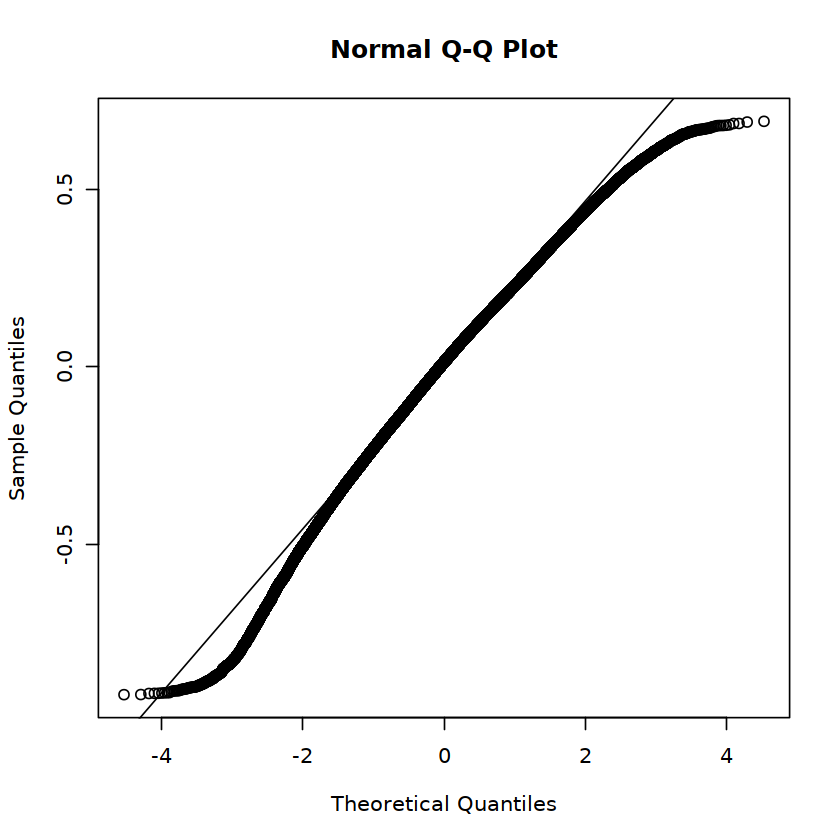

In [39]:
f <- paste0("Apolipoprotein_B~ukbb.centre+sex+age+sex_age+sex_age2+sex_age3+",PCs)
f <- paste0("Apolipoprotein_B~ukbb.centre+",PCs)
fit <- lm(as.formula(f), data = d)
r <- residuals(fit)
print(f)
qqnorm(r)
qqline(r)

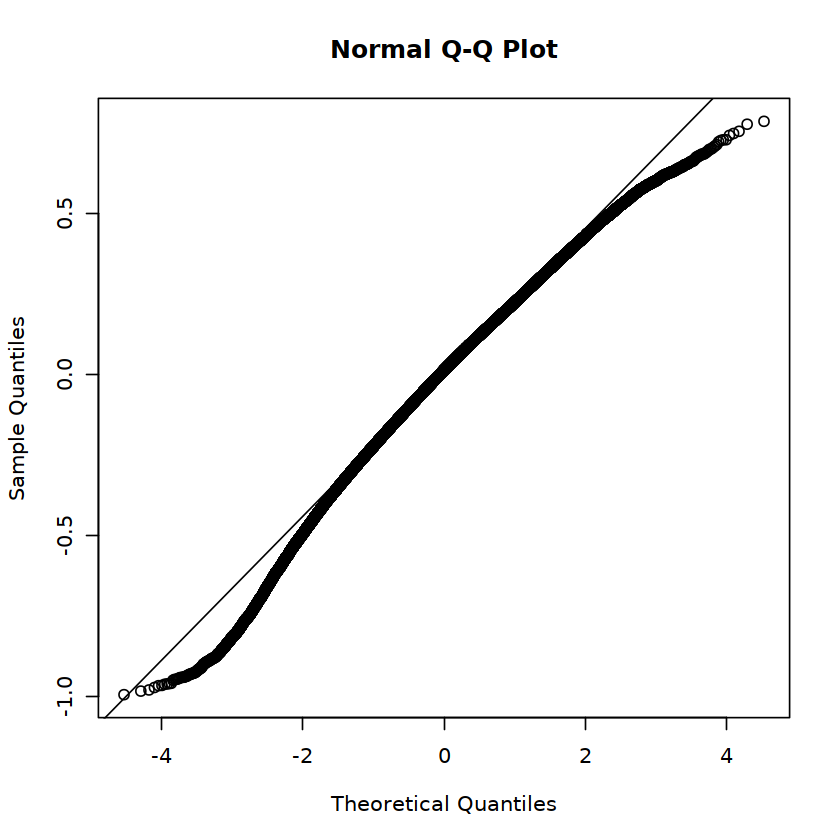

In [41]:
r <- d$Apolipoprotein_B_residual
qqnorm(r)
qqline(r)

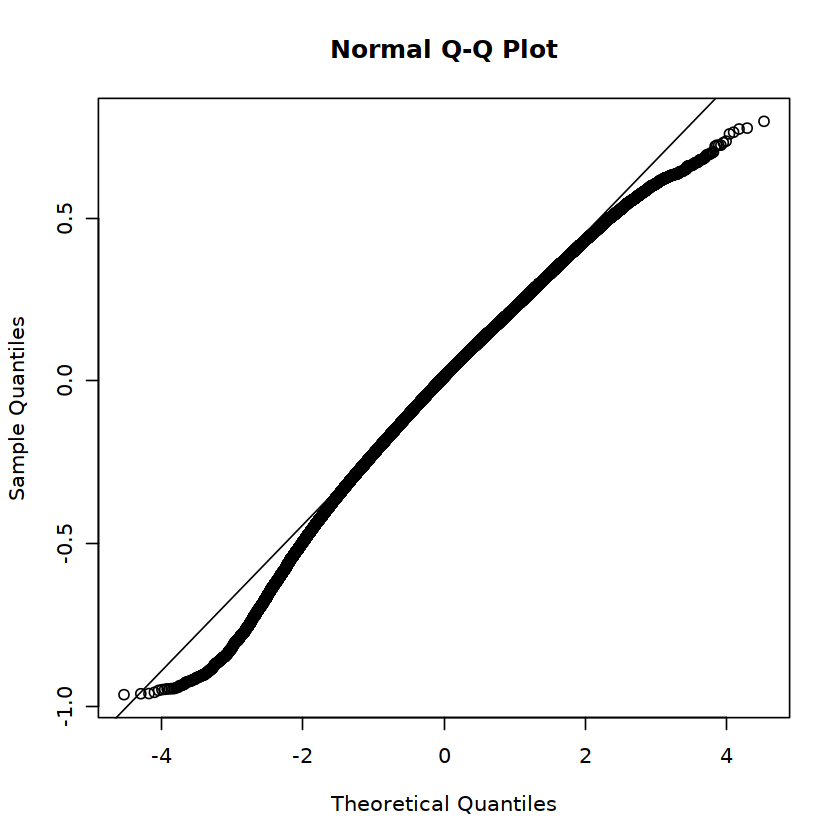

In [43]:
r <- d$Apolipoprotein_B_residual_sex_strat
qqnorm(r)
qqline(r)

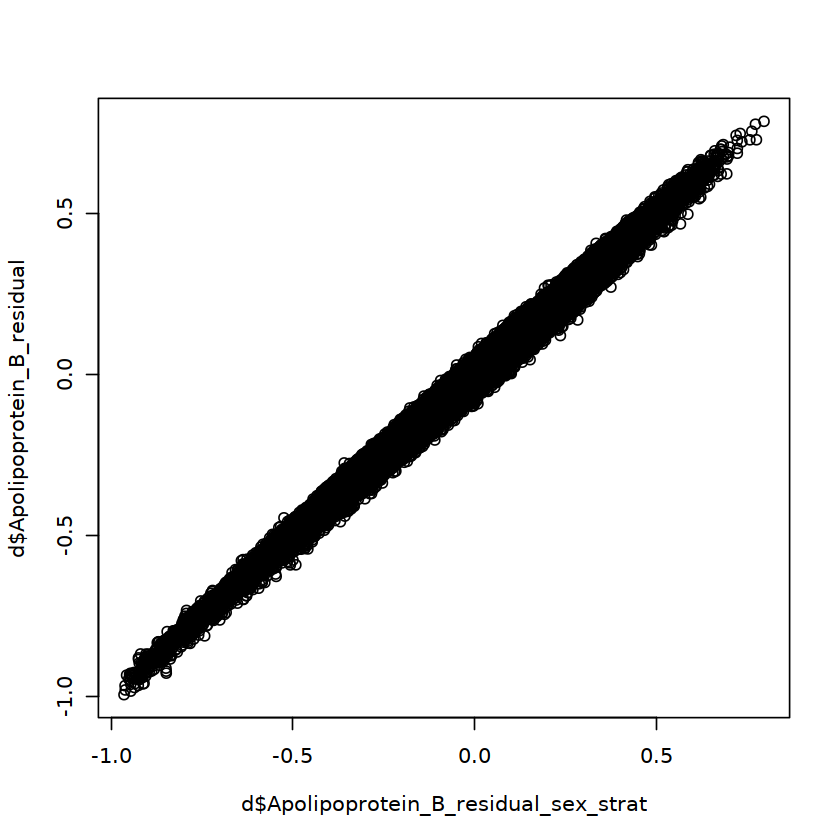

In [45]:
plot(d$Apolipoprotein_B_residual_sex_strat, d$Apolipoprotein_B_residual)

In [342]:
prs <- readRDS("data/prs/scores/auto/prs_auto_Alkaline_Phosphatase_residual_chr1_chains.rda")

In [343]:
str(prs)

List of 30
 $ :List of 9
  ..$ beta_est   : num [1:96201] -4.02e-07 -3.05e-07 -2.27e-07 -3.14e-07 8.25e-07 ...
  ..$ postp_est  : num [1:96201] 0.000432 0.000396 0.000376 0.000405 0.000541 ...
  ..$ sample_beta: num[1:96201, 0 ] 
  ..$ p_est      : num 0.00198
  ..$ h2_est     : num 0.045
  ..$ path_p_est : num [1:1500] 0.000762 0.001157 0.001471 0.001608 0.001972 ...
  ..$ path_h2_est: num [1:1500] 0.0417 0.0452 0.0444 0.0436 0.0449 ...
  ..$ h2_init    : num 0.0203
  ..$ p_init     : num 1e-04
 $ :List of 9
  ..$ beta_est   : num [1:96201] -3.78e-07 -2.86e-07 -2.13e-07 -2.94e-07 7.67e-07 ...
  ..$ postp_est  : num [1:96201] 0.000408 0.000374 0.000355 0.000382 0.000508 ...
  ..$ sample_beta: num[1:96201, 0 ] 
  ..$ p_est      : num 0.00191
  ..$ h2_est     : num 0.0448
  ..$ path_p_est : num [1:1500] 0.000991 0.001499 0.00207 0.002352 0.002289 ...
  ..$ path_h2_est: num [1:1500] 0.045 0.0408 0.0451 0.0461 0.0457 ...
  ..$ h2_init    : num 0.0203
  ..$ p_init     : num 0.000137
 $ :Lis

In [344]:
beta_auto <- sapply(prs, function(auto){
          auto$beta_est})

In [355]:
20/250

[1] 0.08

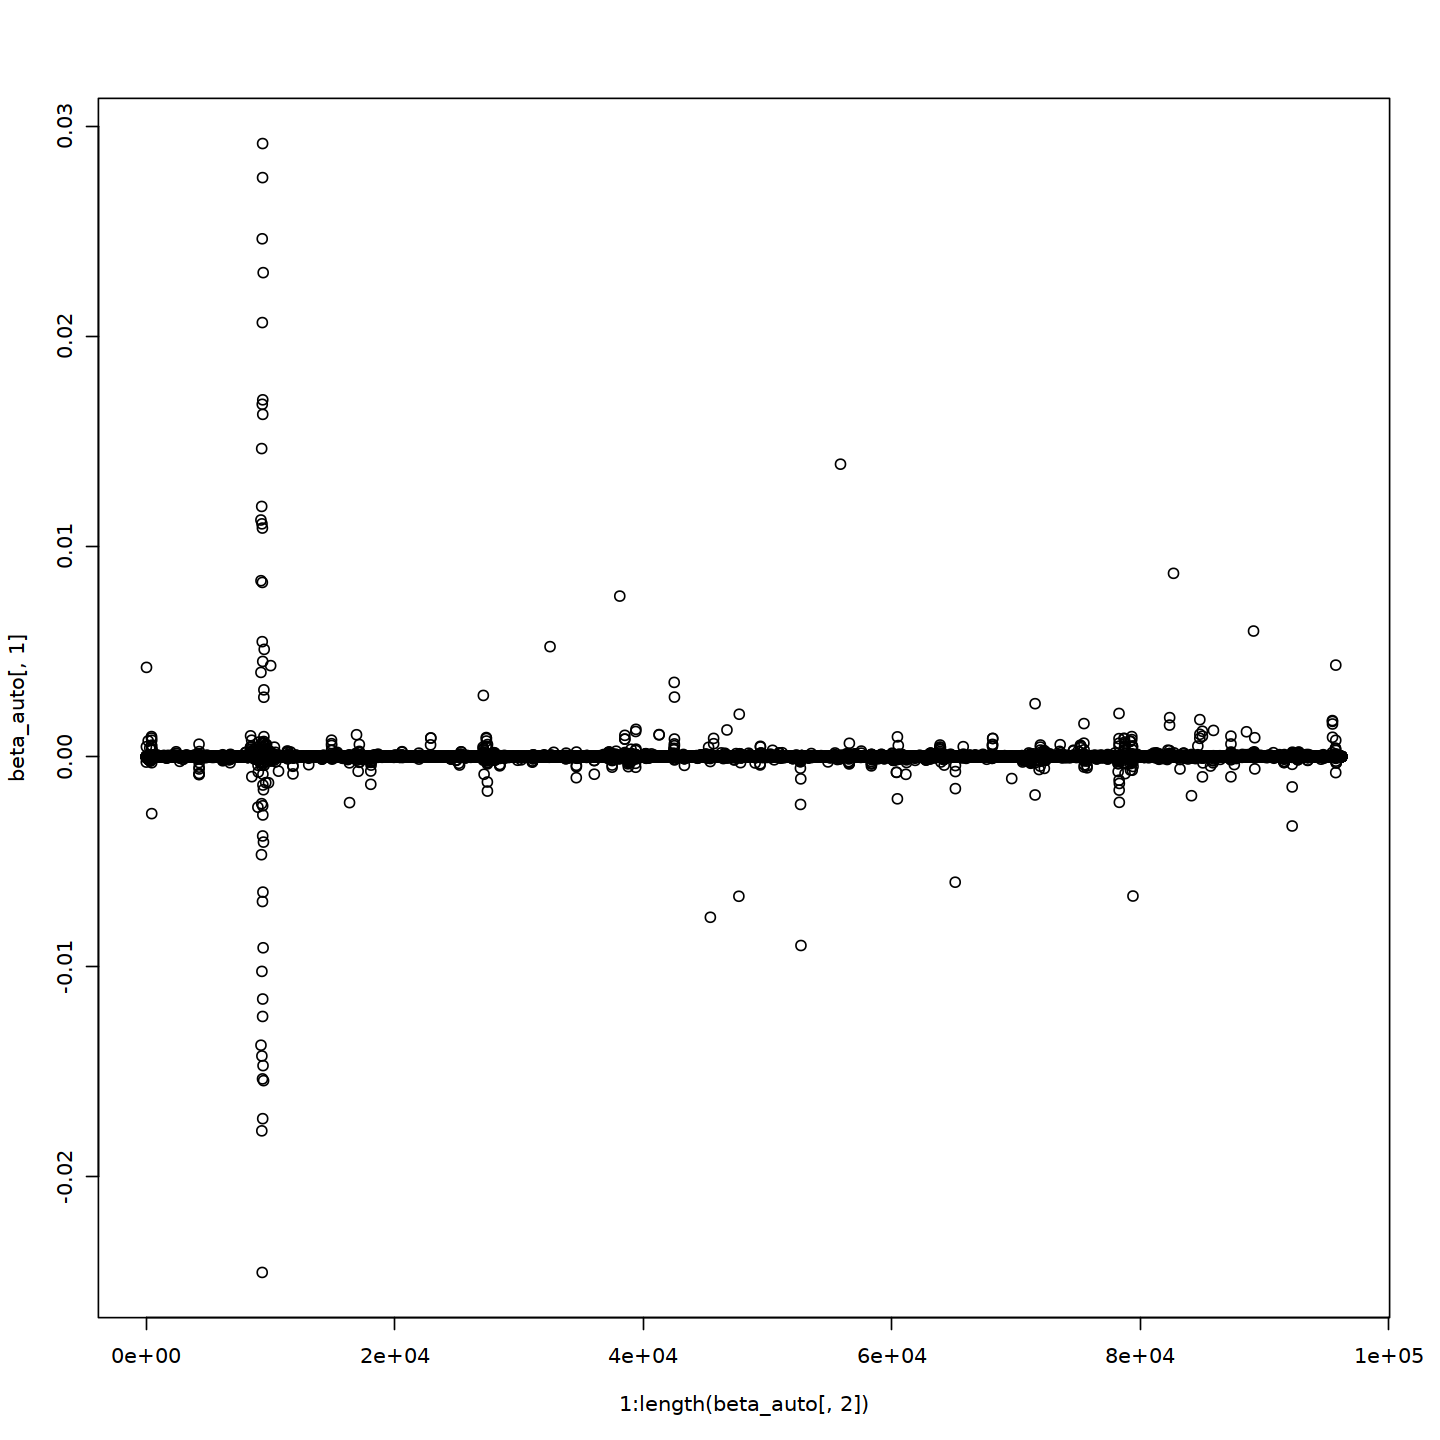

In [354]:
plot(1:length(beta_auto[,2]), beta_auto[,1]);

In [356]:
gwas <- fread('data/prs/sumstat/cts/ukb_hapmap_500k_eur_Alkaline_Phosphatase_residual_chr1.txt.gz')

In [358]:
nrow(gwas)

[1] 96434

locus,alleles,n,sum_x,y_transpose_x,beta,standard_error,t_stat,p_value,AN,AC,AF,a0,a1
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<chr>,<chr>
chr1:21439960,"[""A"",""C""]",140406,114560,2514.7,0.038728,0.0010200,37.970,7.1261e-314,762486,310384,0.40707,A,C
chr1:21495387,"[""A"",""G""]",140406,112430,2150.0,0.033558,0.0010253,32.731,4.3467e-234,762488,304979,0.39998,A,G
chr1:21459575,"[""C"",""T""]",140406,132960,-2363.0,-0.032123,0.0010039,-31.997,7.6564e-224,762488,362003,0.47477,C,T
chr1:21468895,"[""A"",""G""]",140406,152690,-2298.7,-0.031104,0.0010063,-30.909,4.5879e-209,762488,415772,0.54528,A,G
chr1:21486659,"[""T"",""G""]",140406,216560,-1918.7,-0.034924,0.0011939,-29.252,1.5605e-187,762488,587741,0.77082,T,G
chr1:21496799,"[""C"",""T""]",140406,139280,-2168.1,-0.029359,0.0010063,-29.174,1.4933e-186,762488,379051,0.49712,C,T


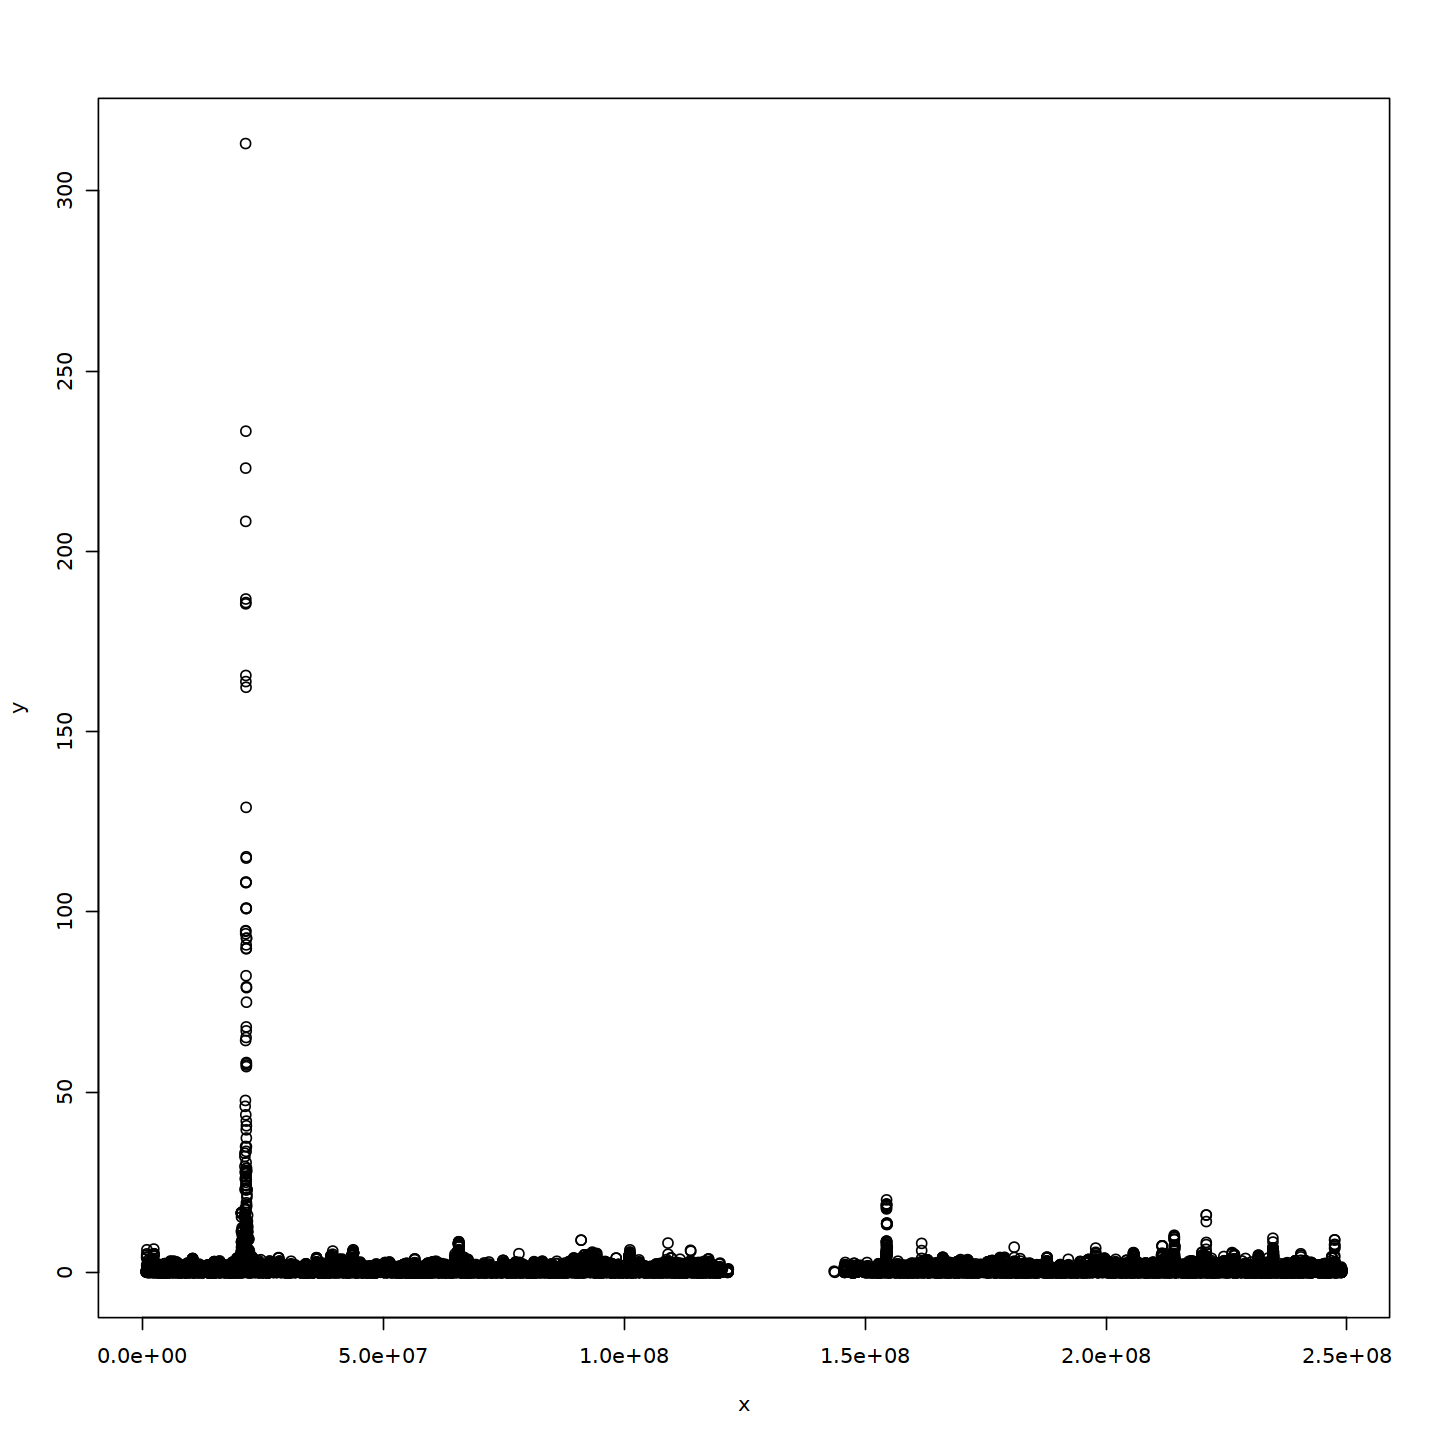

In [371]:
head(gwas[order(gwas$p_value)])
y = -log10(gwas$p_value)
x = as.numeric(gsub("chr1:","",gwas$locus))
plot(x=x,y=y)

In [6]:
#phenotypes <- fread("data/phenotypes/filtered_phenotypes_cts.tsv")
phenotypes <- fread("data/phenotypes/filtered_phenotypes_cts.tsv")

In [7]:
bridge <- fread("/well/lindgren/flassen/ressources/genesets/genesets/data/biomart/220524_hgnc_ensg_enst_chr_pos.txt.gz")

In [8]:
ensembl_to_hgnc <- bridge$hgnc_symbol
names(ensembl_to_hgnc) <- bridge$ensembl_gene_id

In [55]:
ribbon_p <- 0.95
trait <- "cts"
phenotypes <- fread(paste0("data/phenotypes/filtered_phenotypes_",trait,".tsv"))
phenos <- colnames(phenotypes)
null_omit <- function(lst) lst[-which(sapply(lst, is.null))]
lst <- lapply(phenos, function(ph) {
    path_normal <- paste0("data/saige/output/",trait,"/step2/min_mac4/ukb_eur_wes_200k_maf0to5e-2_",ph,"_pLoF_damaging_missense.txt.gz")
    path_prs <- paste0("data/saige/output/",trait,"/step2/min_mac4/ukb_eur_wes_200k_maf0to5e-2_",ph,"_pLoF_damaging_missense_locoprs.txt.gz" ) 
    if (file.exists(path_normal) & file.exists(path_prs)){
        print(ph)
        d_normal <- fread(path_normal)
        d_prs <- fread(path_prs)
        cols = c("MarkerID","p.value")
        
        # setup regular and prs variables
        d_normal = d_normal[,colnames(d_normal) %in% cols, with = FALSE]
        d_prs = d_prs[,colnames(d_prs) %in% cols, with = FALSE]
        colnames(d_prs)[2] <- "p.value_prs"
        d <- merge(d_normal, d_prs, by = "MarkerID")
        
        # melt data
        colnames(d)[2:3] <- c("without_prs","with_prs")
        dt <- melt(d, id.vars = c("MarkerID"), variable.name = "test", value.name = "Pvalue")
        dt$Pvalue <- -log10(dt$Pvalue)
        
        # combine data
        dt <- data.table(
            dt %>% arrange(test, desc(Pvalue)) %>% select(-test),
            dt %>% group_by(test) %>% arrange(desc(Pvalue)) %>% 
                summarize(
                Pvalue_expected = -log10(seq(1, n())/(n() + 1)),
                clower = -log10(qbeta(p = (1 - ribbon_p) / 2, shape2 = n():1, shape1 = 1:n())),
                cupper = -log10(qbeta(p = (1 + ribbon_p) / 2, shape2 = n():1, shape1 = 1:n()))
                )
            )
        
        dt$phenotype <- ph
        markers <- head(dt[rev(order(dt$Pvalue))]$MarkerID, n = 3)
        dt$label <- NA
        dt$label[dt$MarkerID %in% markers] <- ensembl_to_hgnc[dt$MarkerID[dt$MarkerID %in% markers]]
        return(dt)

    }

})
lst <- null_omit(lst)

[1] "Albumin_residual"


`summarise()` has grouped output by 'test'. You can override using the `.groups` argument.



[1] "Alkaline_Phosphatase_residual"


`summarise()` has grouped output by 'test'. You can override using the `.groups` argument.



[1] "Apolipoprotein_A_residual"


...

`summarise()` has grouped output by 'test'. You can override using the `.groups` argument.



[1] "BMI"


`summarise()` has grouped output by 'test'. You can override using the `.groups` argument.



[1] "BMI_imp"


`summarise()` has grouped output by 'test'. You can override using the `.groups` argument.



In [56]:
dts <- do.call(rbind, lst)

Warning message:
"Ignoring unknown parameters: label.padding"
Warning message:
"Removed 53692 rows containing missing values (geom_text_repel)."


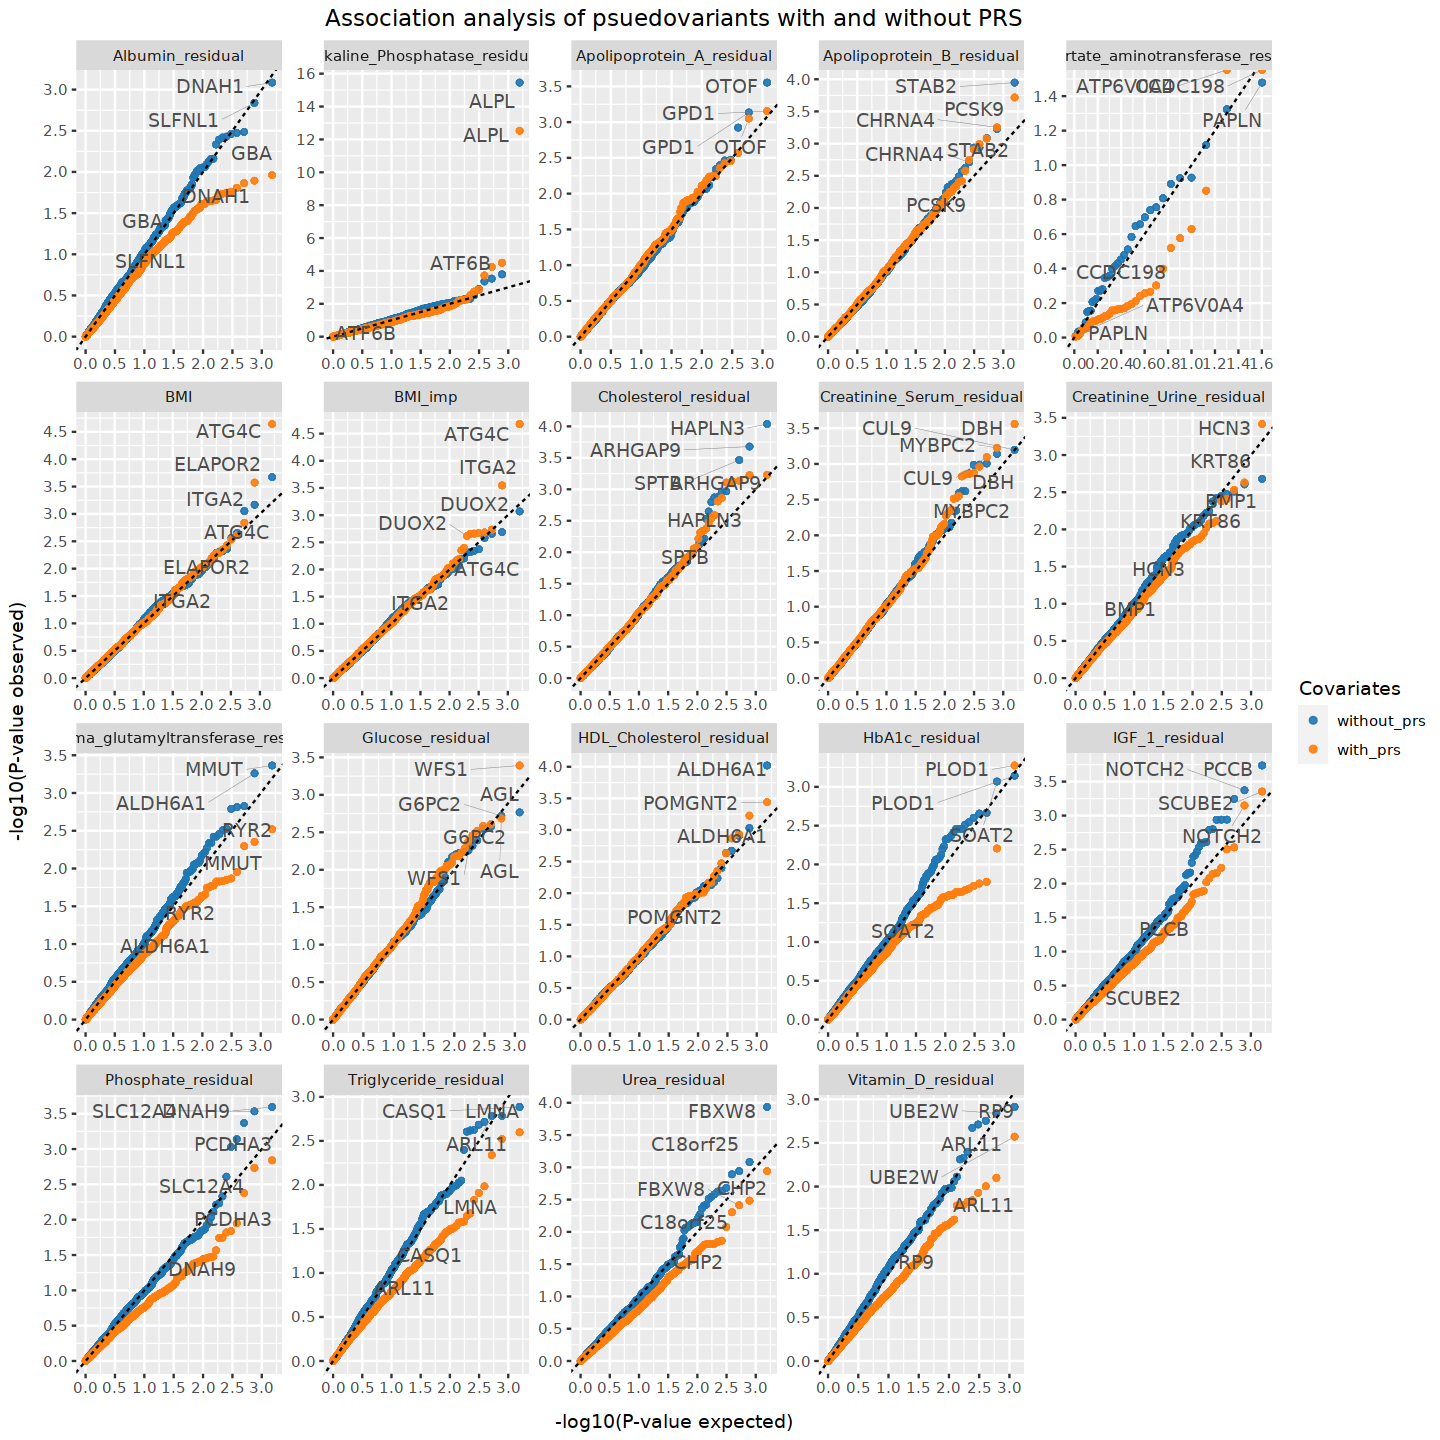

In [57]:
options(repr.plot.width=12, repr.plot.height=12)
n_x_ticks=10
n_y_ticks=10
alpha = 0.9

ggplot(dts, aes(x=Pvalue_expected, y = Pvalue, color = test, label = label)) +
    geom_point_rast(alpha=alpha, raster.dpi=500) +
    geom_abline(linetype = 'dashed') +
    geom_text_repel(
        box.padding = 0.4, label.padding=0.1, point.padding = 0.2,
        color = 'grey30', segment.color = 'grey50', max.overlaps=Inf,
        size=4, segment.size=0.1, show.legend = FALSE
    ) + 
    ggtitle("Association analysis of psuedovariants with and without PRS") +
    xlab("-log10(P-value expected)") + 
    ylab("-log10(P-value observed)") +
    scale_color_d3('category20', limits=NULL) +
    labs(color=paste0("Covariates")) +
    scale_x_continuous(breaks=scales::pretty_breaks(n=n_x_ticks)) +
    scale_y_continuous(breaks=scales::pretty_breaks(n=n_y_ticks)) +
    theme(axis.title.x = element_text(margin=ggplot2::margin(t=10)),
          axis.title.y = element_text(margin=ggplot2::margin(r=10)),
          plot.title = element_text(hjust=0.5)) +
    facet_wrap(~phenotype, scales = "free")


In [58]:
# Function to add histograms
panel.hist <- function(x, ...) {
    usr <- par("usr")
    on.exit(par(usr))
    par(usr = c(usr[1:2], 0, 1.5))
    his <- hist(x, plot = FALSE)
    breaks <- his$breaks
    nB <- length(breaks)
    y <- his$counts
    y <- y/max(y)
    rect(breaks[-nB], 0, breaks[-1], y, col = rgb(0, 1, 1, alpha = 0.5), ...)
    # lines(density(x), col = 2, lwd = 2) # Uncomment to add density lines
}



In [59]:
test <- fread("data/prs/scores/Alkaline_Phosphatase_residual_pgs_chrom.txt.gz")

In [ ]:
options(repr.plot.width=18, epr.plot.height=12)
# Creating the scatter plot matrix
pairs(test[,-1],
      upper.panel = NULL,         # Disabling the upper panel
      diag.panel = panel.hist)    # Adding the histograms

In [18]:
scores <- fread('data/prs/scores/ldsc_summary.txt')

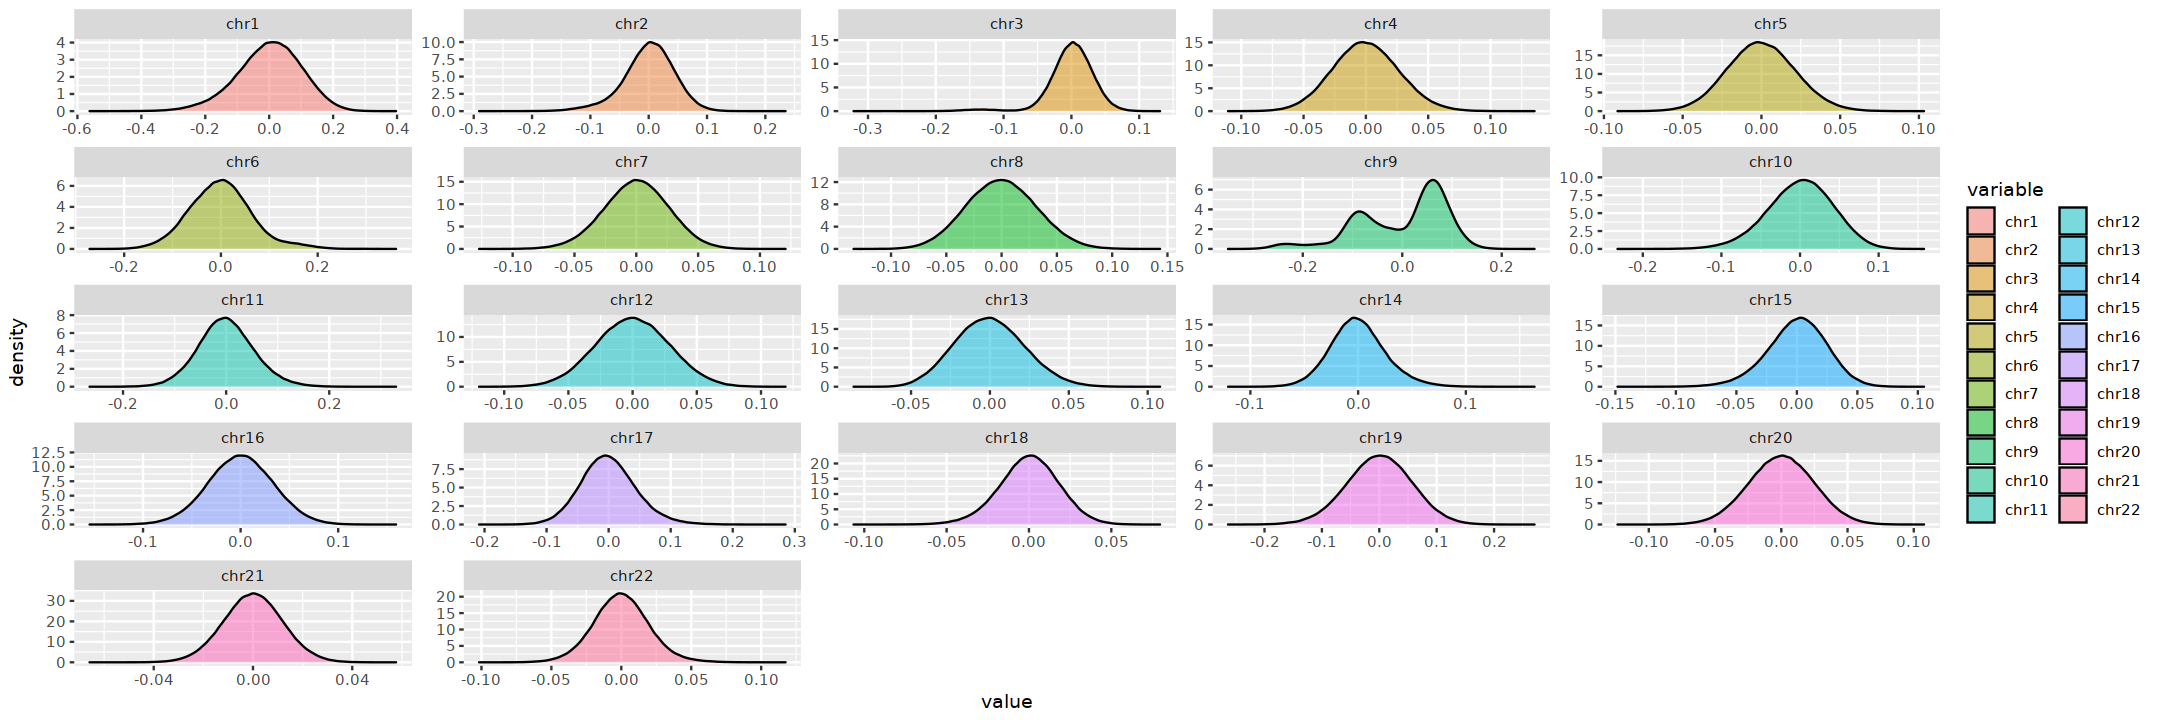

In [48]:
options(repr.plot.width=18, epr.plot.height=6)
test <- fread("data/prs/scores/Alkaline_Phosphatase_residual_pgs_chrom.txt.gz")
melted_test <- melt(test, id.vars = "sid", measure.vars = paste0("chr",1:22))
ggplot(melted_test, aes(x=value, fill = variable)) +
    geom_density(alpha = 0.5) + facet_wrap(~variable, scale = "free")

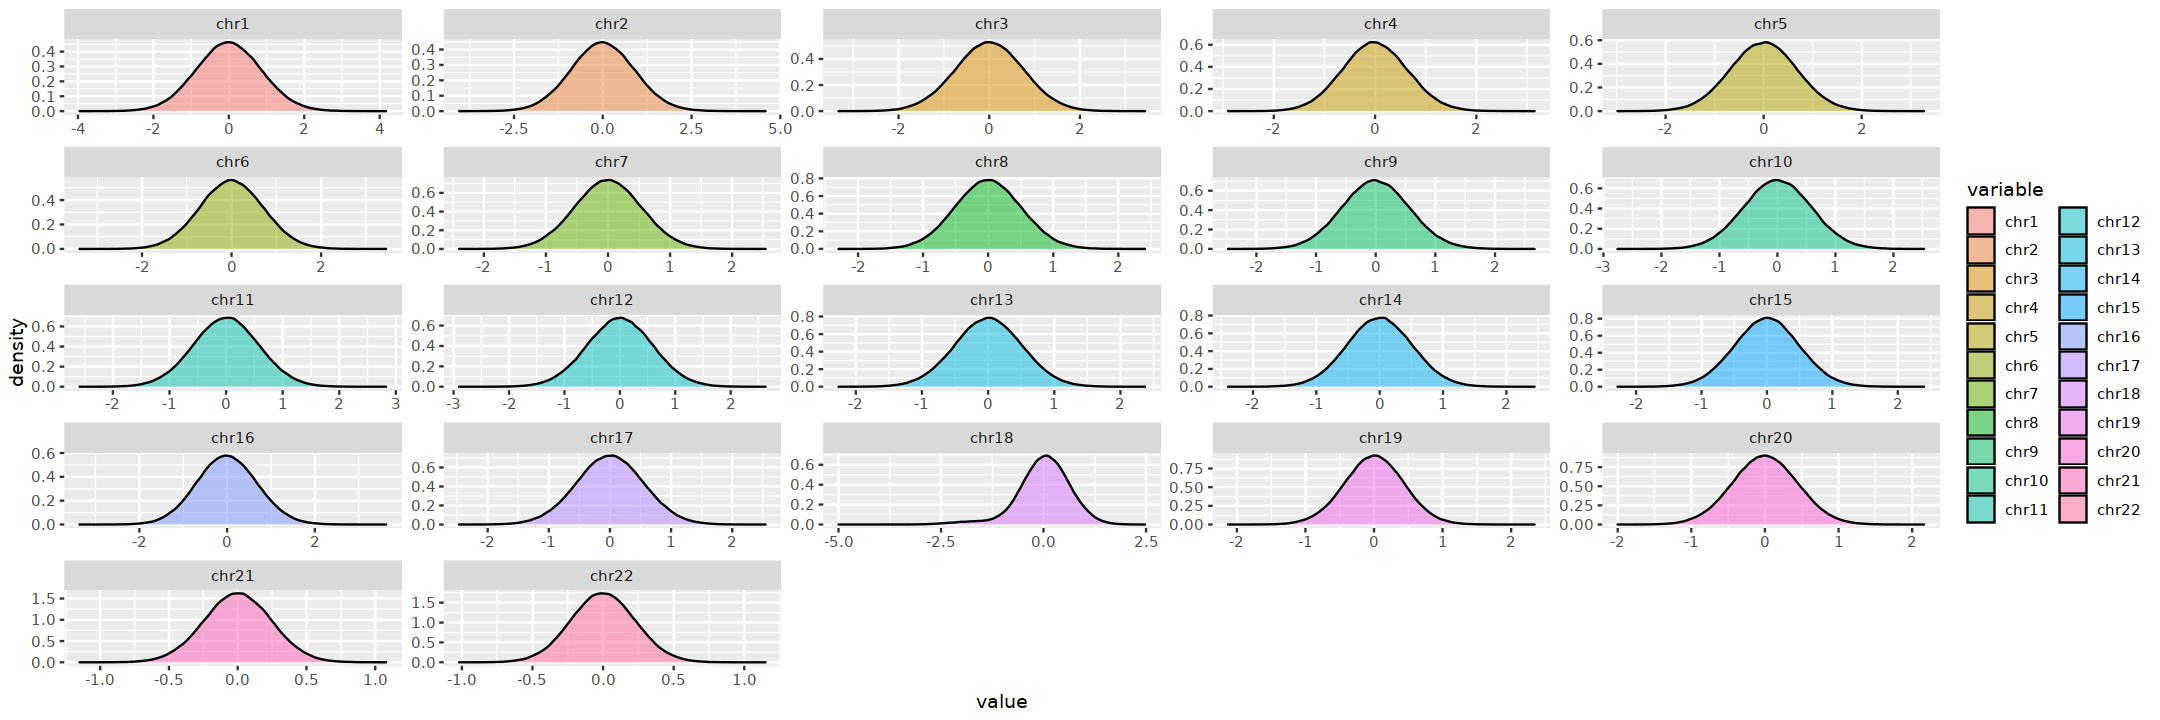

In [47]:
options(repr.plot.width=18, epr.plot.height=6)
test <- fread("data/prs/scores/BMI_pgs_chrom.txt.gz")
melted_test <- melt(test, id.vars = "sid", measure.vars = paste0("chr",1:22))
ggplot(melted_test, aes(x=value, fill = variable)) +
    geom_density(alpha = 0.5) + facet_wrap(~variable, scales = "free")

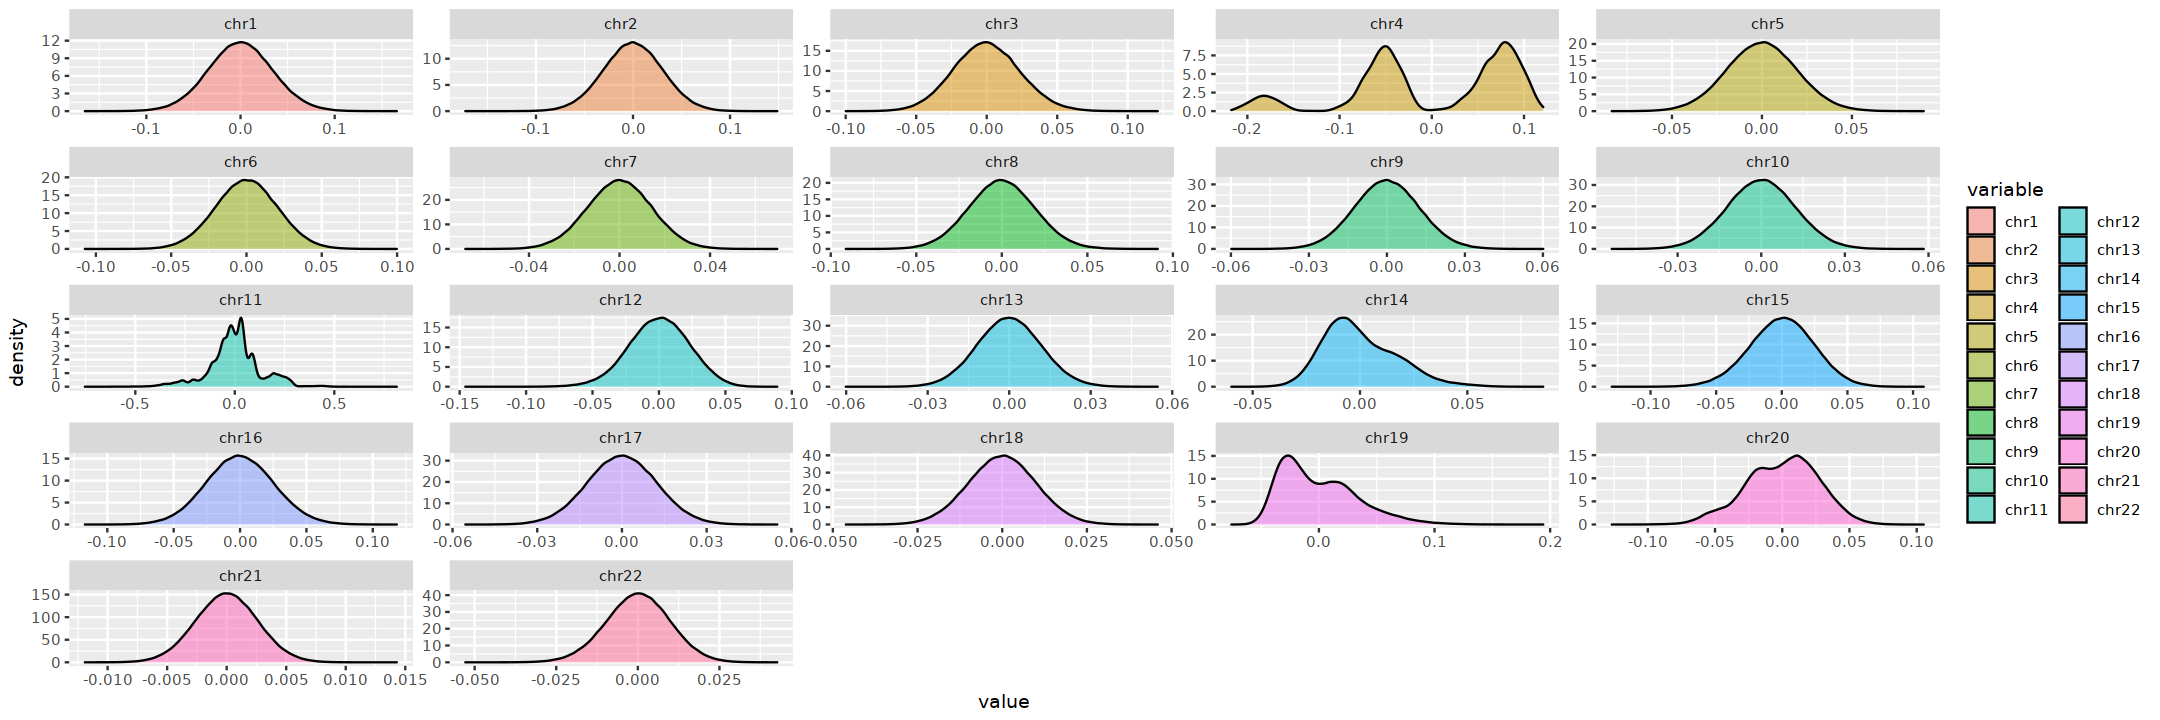

In [46]:
options(repr.plot.width=18, epr.plot.height=6)
test <- fread("data/prs/scores/Vitamin_D_residual_pgs_chrom.txt.gz")
melted_test <- melt(test, id.vars = "sid", measure.vars = paste0("chr",1:22))
ggplot(melted_test, aes(x=value, fill = variable)) +
    geom_density(alpha = 0.5) + facet_wrap(~variable, scales = "free")

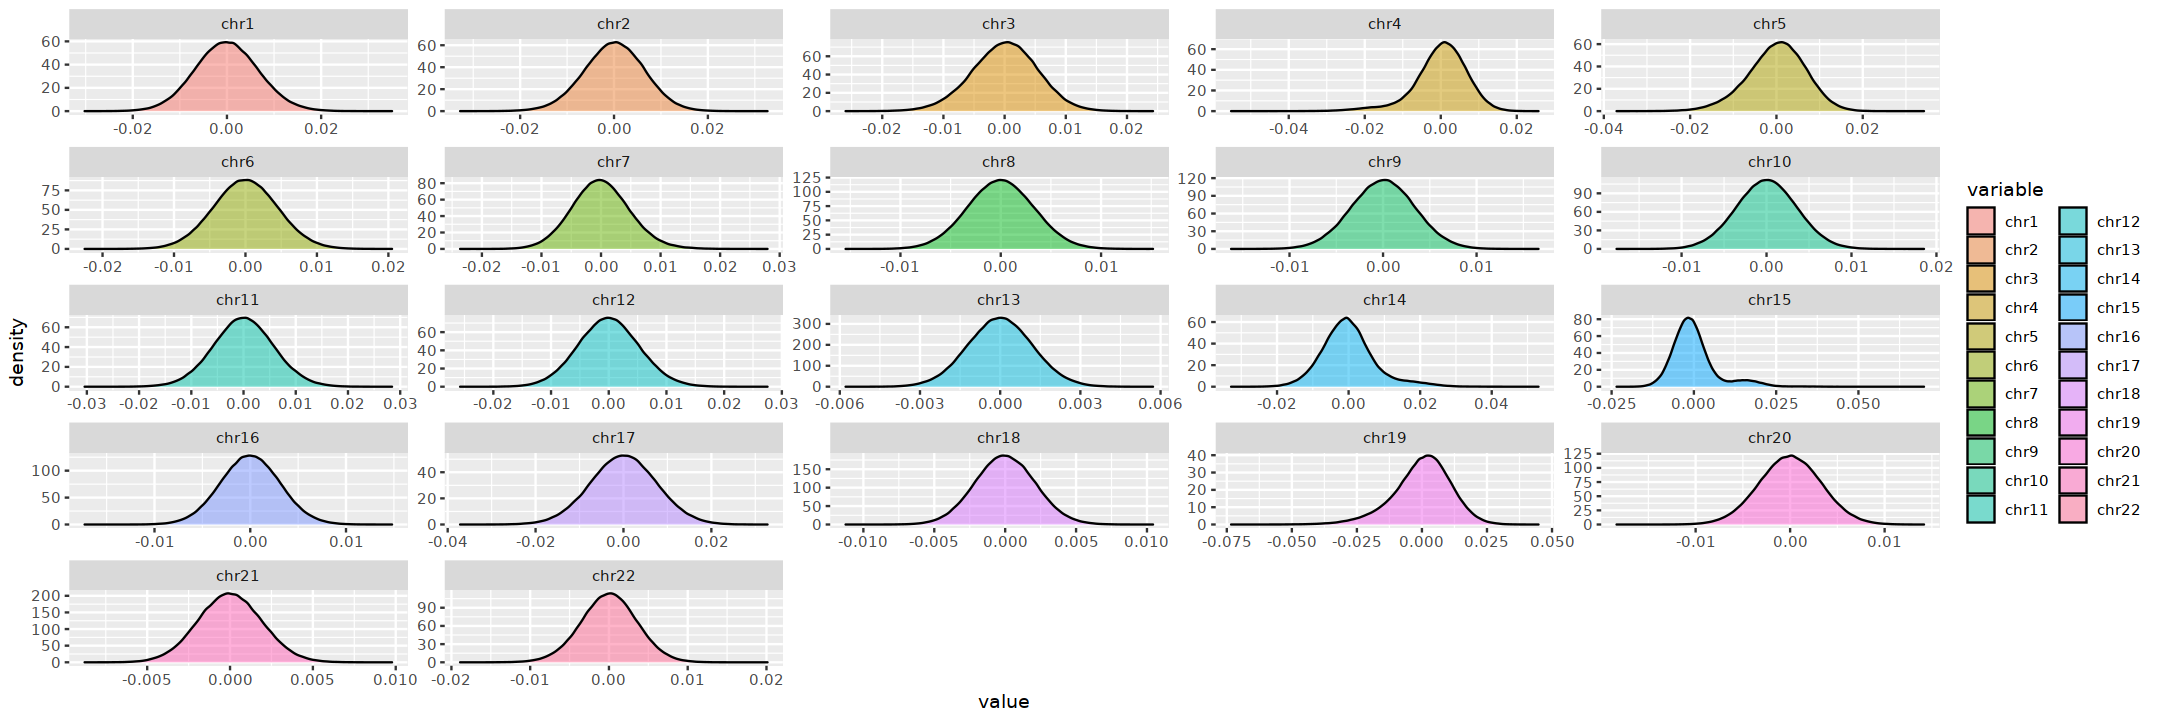

In [49]:
options(repr.plot.width=18, epr.plot.height=6)
test <- fread("data/prs/scores/Albumin_residual_pgs_chrom.txt.gz")
melted_test <- melt(test, id.vars = "sid", measure.vars = paste0("chr",1:22))
ggplot(melted_test, aes(x=value, fill = variable)) +
    geom_density(alpha = 0.5) + facet_wrap(~variable, scales = "free")

In [51]:
options(repr.plot.width=18, epr.plot.height=6)
test <- fread("data/prs/scores/ Apolipoprotein_B_residual_pgs_chrom.txt.gz")
melted_test <- melt(test, id.vars = "sid", measure.vars = paste0("chr",1:22))
ggplot(melted_test, aes(x=value, fill = variable)) +
    geom_density(alpha = 0.5) + facet_wrap(~variable, scales = "free")

ERROR: Error in fread("data/prs/scores/old/Apolipoprotein_B_residual_pgs_chrom.txt.gz"): File 'data/prs/scores/old/Apolipoprotein_B_residual_pgs_chrom.txt.gz' does not exist or is non-readable. getwd()=='/gpfs3/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb'


In [28]:
colnames(phenotypes)

[1] "eid"                                  
  [2] "Alanine_aminotransferase"             
  [3] "Albumin"                              
  [4] "Alkaline_Phosphatase"                 
  [5] "Apolipoprotein_A"                     
  [6] "Apolipoprotein_B"                     
  [7] "Aspartate_aminotransferase"           
  [8] "C_reactive_Protein"                   
  [9] "Calcium"                              
 [10] "Cholesterol"                          
 [11] "Creatinine_Serum"                     
 [12] "Creatinine_Urine"                     
 [13] "Cystatin_C_Serum"                     
 [14] "Direct_Bilirubin"                     
 [15] "Gamma_glutamyltransferase"            
 [16] "Glucose"                              
 [17] "HbA1c"                                
 [18] "HDL_Cholesterol"                      
 [19] "IGF_1"                                
 [20] "Lipoprotein_A"                        
 [21] "Microalbumin_Urine"                   
 [22] "Oestradiol"                           
 [23] "Phosphate"                            
 [24] "Potassium_Urine"                      
 [25] "Rheumatoid_factor"                    
 [26] "SHBG"                                 
 [27] "Sodium_Urine"                         
 [28] "Testosterone"                         
 [29] "Total_Bilirubin"                      
 [30] "Total_Protein"                        
 [31] "Triglyceride"                         
 [32] "Urate"                                
 [33] "Urea"                                 
 [34] "Vitamin_D"                            
 [35] "Alanine_aminotransferase_residual"    
 [36] "Albumin_residual"                     
 [37] "Alkaline_Phosphatase_residual"        
 [38] "Apolipoprotein_A_residual"            
 [39] "Apolipoprotein_B_residual"            
 [40] "Aspartate_aminotransferase_residual"  
 [41] "C_reactive_Protein_residual"          
 [42] "Calcium_residual"                     
 [43] "Cholesterol_residual"                 
 [44] "Creatinine_Serum_residual"            
 [45] "Creatinine_Urine_residual"            
 [46] "Cystatin_C_Serum_residual"            
 [47] "Direct_Bilirubin_residual"            
 [48] "Gamma_glutamyltransferase_residual"   
 [49] "Glucose_residual"                     
 [50] "HbA1c_residual"                       
 [51] "HDL_Cholesterol_residual"             
 [52] "IGF_1_residual"                       
 [53] "Lipoprotein_A_residual"               
 [54] "Microalbumin_Urine_residual"          
 [55] "Oestradiol_residual"                  
 [56] "Phosphate_residual"                   
 [57] "Potassium_Urine_residual"             
 [58] "Rheumatoid_factor_residual"           
 [59] "SHBG_residual"                        
 [60] "Sodium_Urine_residual"                
 [61] "Testosterone_residual"                
 [62] "Total_Bilirubin_residual"             
 [63] "Total_Protein_residual"               
 [64] "Triglyceride_residual"                
 [65] "Urate_residual"                       
 [66] "Urea_residual"                        
 [67] "Vitamin_D_residual"                   
 [68] "Alanine_aminotransferase_M_residual"  
 [69] "Albumin_M_residual"                   
 [70] "Alkaline_Phosphatase_M_residual"      
 [71] "Apolipoprotein_A_M_residual"          
 [72] "Apolipoprotein_B_M_residual"          
 [73] "Aspartate_aminotransferase_M_residual"
 [74] "C_reactive_Protein_M_residual"        
 [75] "Calcium_M_residual"                   
 [76] "Cholesterol_M_residual"               
 [77] "Creatinine_Serum_M_residual"          
 [78] "Creatinine_Urine_M_residual"          
 [79] "Cystatin_C_Serum_M_residual"          
 [80] "Direct_Bilirubin_M_residual"          
 [81] "Gamma_glutamyltransferase_M_residual" 
 [82] "Glucose_M_residual"                   
 [83] "HbA1c_M_residual"                     
 [84] "HDL_Cholesterol_M_residual"           
 [85] "IGF_1_M_residual"                     
 [86] "Lipoprotein_A_M_residual"             
 [87] "Microalbumin_Urine_M_residual"        


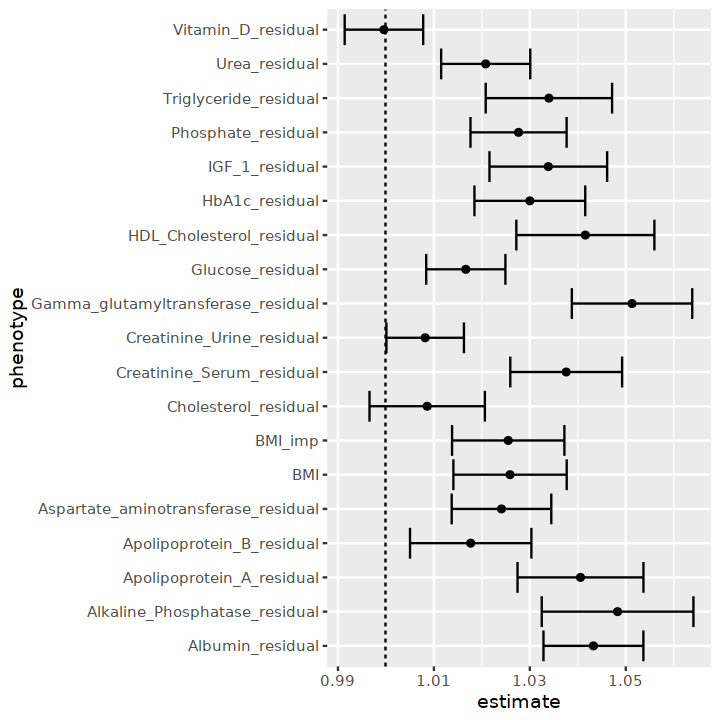

In [26]:
options(repr.plot.width=6, repr.plot.height=6)
ggplot(scores[scores$phenotype %in% dts$phenotype & scores$coef == "intercept",], 
       aes(x=estimate, xmax=estimate + std_error, xmin=estimate - std_error, y=phenotype)) +
        geom_point() +
        geom_errorbar() +
        geom_vline(xintercept = 1, linetype = 'dashed')

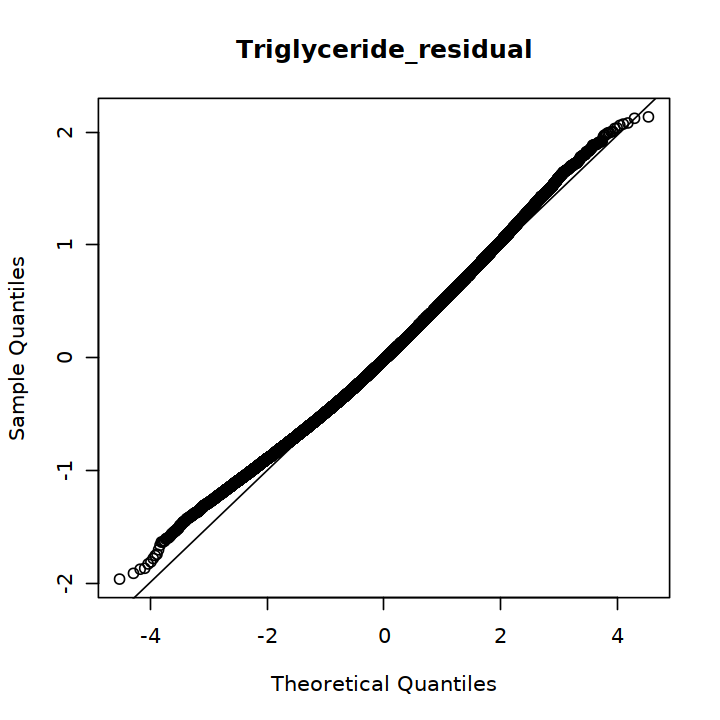

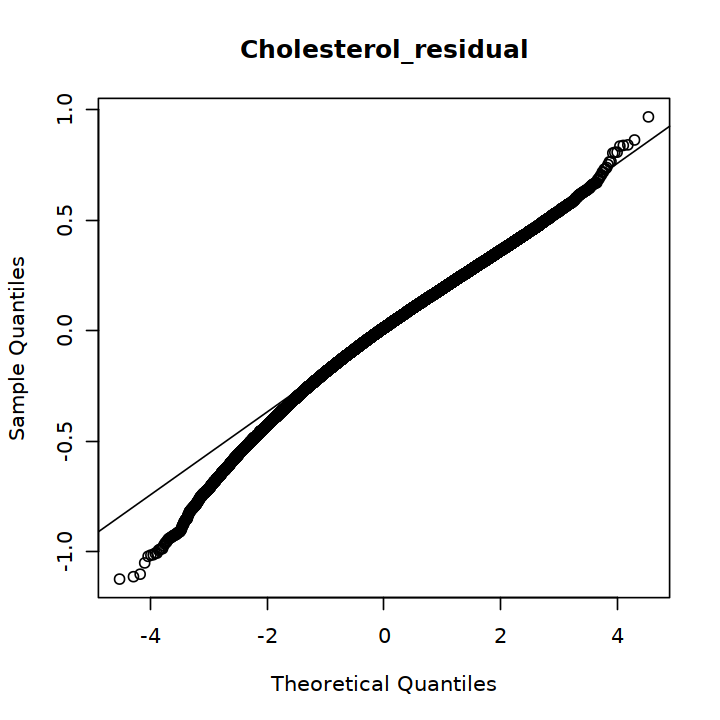

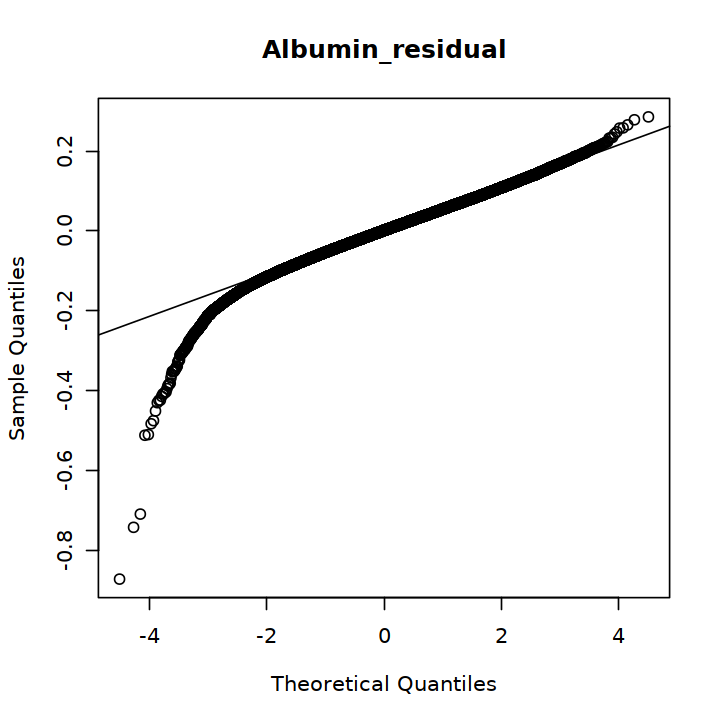

In [27]:
options(repr.plot.width=6, repr.plot.height=6)
qqnorm(phenotypes$Triglyceride_residual, main = "Triglyceride_residual")
qqline(phenotypes$Triglyceride_residual)
qqnorm(phenotypes$Cholesterol_residual, main = "Cholesterol_residual")
qqline(phenotypes$Cholesterol_residual)
qqnorm(phenotypes$Albumin_residual, main = "Albumin_residual")
qqline(phenotypes$Albumin_residual)

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.



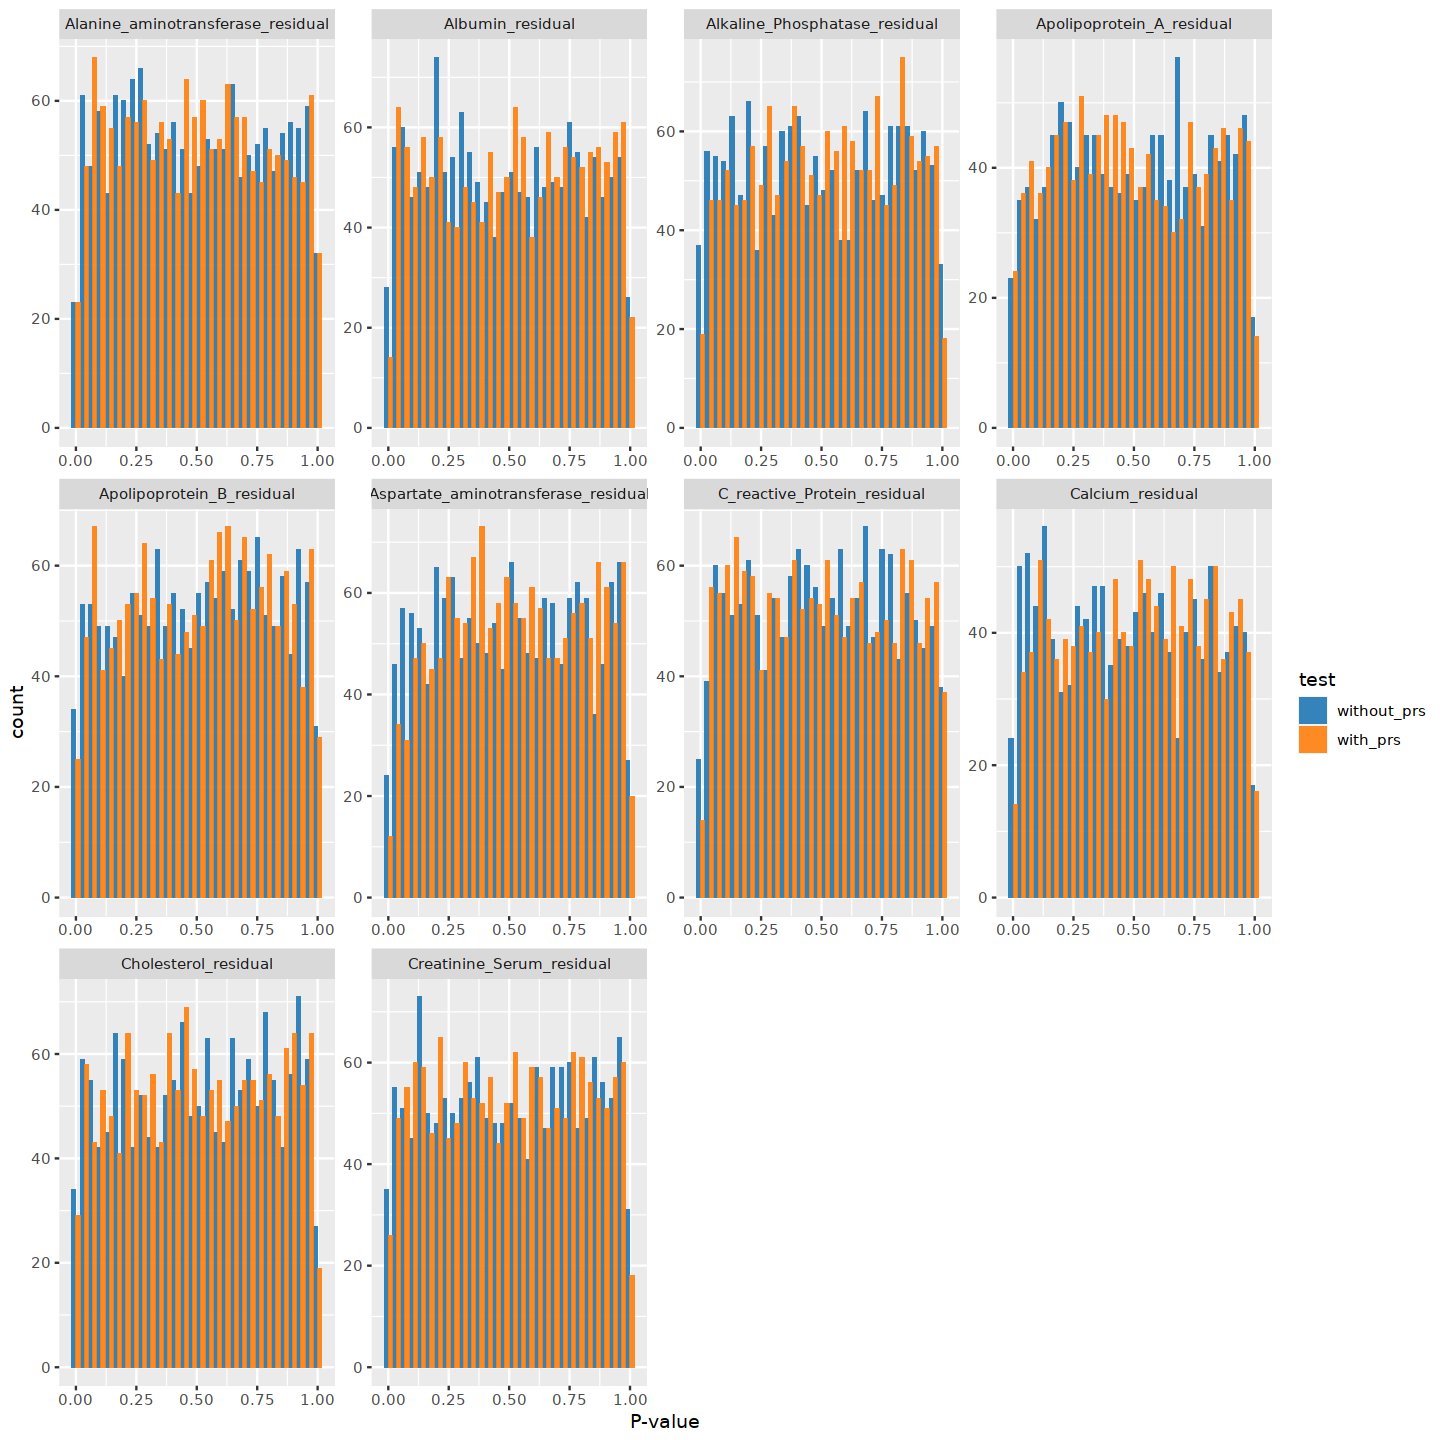

In [338]:
ggplot(dts, aes(x = 10^(-Pvalue), fill = test)) +
    geom_histogram(alpha = 0.9, position = 'dodge') +
    scale_fill_d3('category20', limits=NULL) +
    facet_wrap(~phenotype, scales = "free") +
    xlab("P-value")

In [185]:
#d$p.value_expt <- get_expected_p(d$p.value)
#d$p.value_prs_expt <- get_expected_p(d$p.value_prs)

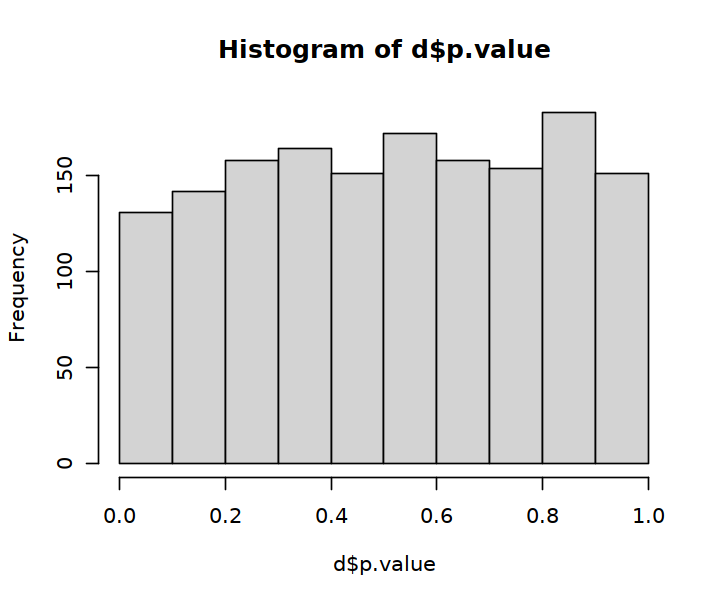

In [186]:
options(repr.plot.width=6, repr.plot.height=5)
hist(d$p.value)

In [187]:
head(d)

MarkerID,p.value,p.value_prs
<chr>,<dbl>,<dbl>
ENSG00000001626,0.4409430,0.0399490
ENSG00000003989,0.5375190,0.6081970
ENSG00000004139,0.5387510,0.8670310
ENSG00000004700,0.0529889,0.0746161
ENSG00000004846,0.4543190,0.7936240
ENSG00000005381,0.6032490,0.9770470


In [188]:
colnames(d)[2:3] <- c("without_prs","with_prs")
dt <- melt(d, id.vars = c("MarkerID"), variable.name = "test", value.name = "Pvalue")
dt$Pvalue <- -log10(dt$Pvalue)

In [189]:
head(dt)

MarkerID,test,Pvalue
<chr>,<fct>,<dbl>
ENSG00000001626,without_prs,0.3556175
ENSG00000003989,without_prs,0.2696062
ENSG00000004139,without_prs,0.2686119
ENSG00000004700,without_prs,1.2758151
ENSG00000004846,without_prs,0.3426391
ENSG00000005381,without_prs,0.2195034


In [190]:
dt <- data.table(
    dt %>% arrange(test, desc(Pvalue)) %>% select(-test),
    dt %>% group_by(test) %>% arrange(desc(Pvalue)) %>% 
        summarize(
        Pvalue_expected = -log10(seq(1, n())/(n() + 1)),
        clower = -log10(qbeta(p = (1 - ribbon_p) / 2, shape2 = n():1, shape1 = 1:n())),
        cupper = -log10(qbeta(p = (1 + ribbon_p) / 2, shape2 = n():1, shape1 = 1:n()))
        )
    )

`summarise()` has grouped output by 'test'. You can override using the `.groups` argument.



In [ ]:
dt$labels <- 

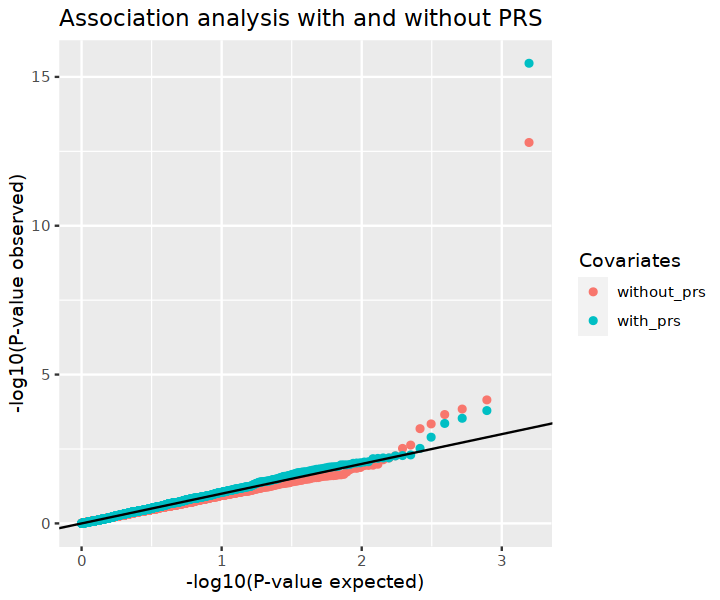

In [108]:
head(d[order(d$p.value)])

MarkerID,p.value,p.value_prs,p.value_expt
<chr>,<dbl>,<dbl>,<dbl>
ENSG00000151348,0.000174211,0.01370350,0.0006393862
ENSG00000088320,0.000403105,0.00883629,0.0012787724
ENSG00000130812,0.000476976,0.08634280,0.0019181586
ENSG00000149922,0.000546563,0.03215640,0.0025575448
ENSG00000163902,0.005237350,0.02055200,0.0031969309
ENSG00000159398,0.007642170,0.03774570,0.0038363171


In [109]:
head(d[order(d$p.value_prs)])

MarkerID,p.value,p.value_prs,p.value_expt
<chr>,<dbl>,<dbl>,<dbl>
ENSG00000119711,0.00772523,5.84957e-05,0.004475703
ENSG00000104774,0.23700100,2.39621e-03,0.246163683
ENSG00000198399,0.04702250,4.16190e-03,0.036445013
ENSG00000171714,0.01082850,4.74049e-03,0.008312020
ENSG00000116819,0.03211760,5.21446e-03,0.026214834
ENSG00000144191,0.09507920,6.41188e-03,0.095907928


In [387]:
devtools::load_all("utils/modules//R//gwastools")

i Loading gwastools

! Skipping missing files: /gpfs3/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/utils/modules/R/gwastools/R/inv_rank_norm.R

! Adding files missing in collate: /gpfs3/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/utils/modules/R/gwastools/R/inv_norm.R

Warning message in setup_ns_exports(path, export_all, export_imports):
"Objects listed as exports, but not present in namespace: summarize_bcftools_trio_stats"


In [423]:
faf <- ifelse(1==2, get_int, get_rint)

In [425]:
faf(1)

[1]  1.259090132  1.112881070 -1.768825039 -0.725858408  1.400565409
   [6]  1.171689214  0.991790692 -0.658625828 -0.141077217 -0.113007016
  [11]  0.960406089  2.062545924  0.113007016           NA  0.700721538
  [16] -0.535454717 -0.777569064 -0.200416016           NA -0.634603095
  [21]  0.032025718  0.004176566 -1.211325657 -0.248964880  0.438249788
  [26] -1.112881070  1.316508783  0.392715938           NA  0.065479435
  [31]  0.374733160 -0.525838708 -0.079437988  1.415571977  0.447463542
  [36] -0.938555712 -1.118068108 -0.851282205           NA -0.160791391
  [41] -0.863345031           NA -0.929940078 -0.541892952 -0.574430969
  [46] -1.082367774  1.617344478 -1.430904279 -0.037597839  0.327348108
  [51]  0.149518989  1.768825039 -0.883734102 -0.034811643  0.947241584
  [56] -0.389710133  0.231768816 -1.617344478 -0.023669347           NA
  [61] -1.062573164 -0.676019841 -0.450543216  0.342072165 -1.014820052
  [66]  0.871457170  1.997042141  0.494127229           NA  1.408029057
  [71]  0.676019841           NA  0.969275671 -1.824763961  1.357338430
  [76] -0.969275671 -0.226052242  0.043171127  0.087820381 -0.101805055
  [81]  0.015314629 -0.018099387 -0.289386694 -1.033638502  0.506750477
  [86] -0.690083582  0.226052242 -0.015314629 -0.459808077           NA
  [91] -1.415571977 -1.976994866  0.747774898 -0.104604293 -0.564607127
  [96]  0.062689341  0.665559246           NA  0.662088558  1.082367774
 [101]  0.545120496           NA  0.831447928 -0.191900622 -1.870806970
 [106]  0.744097402  1.730237269 -0.073852861  1.211325657 -0.581011073
 [111] -0.978222169 -0.847288719  0.183399121  0.597572879 -0.766316639
 [116] -0.804216642 -0.272008990  1.234855738 -0.641428842 -0.359839779
 [121]           NA -0.462905117 -0.506750477           NA  0.365787372
 [126]  0.197575967  1.057689185 -1.462620575 -0.257590279 -1.364366974
 [131]           NA -0.353904888  1.033638502 -2.388013078  0.096208949
 [136] -1.107723803  1.423196307  0.781341786 -0.318547823 -0.487845135
 [141] -0.127029604 -0.665559246 -0.819702984 -0.621039355  2.138317604
 [146] -1.303375658           NA -0.132645486  1.067482621 -0.627806787
 [151] -0.529038601 -0.755160418  1.062573164  0.040384326 -0.051533629
 [156]  0.567875644           NA -0.686554939 -0.617666294 -0.904497346
 [161]  0.435186824 -1.438698214  0.076645126           NA -0.744097402
 [166]  0.020884286           NA -0.532243920  0.141077217  0.018099387
 [171] -0.484711308  0.082231469  0.295198476 -0.435186824           NA
 [176]  0.551592703 -0.947241584           NA  0.118613231  0.071061173
 [181]  0.001392185  0.194737511 -0.223196734 -0.429073089           NA
 [186]           NA -1.479046004 -0.220343045 -0.362811971 -0.324411896
 [191]  1.252962420 -2.039728294  0.475338167  0.672524807 -0.143889994
 [196]  0.172084261 -0.183399121  0.773807376  0.538671044  1.005544312
 [201]  0.614300246  0.584310565  0.917144498 -0.781341786 -0.365787372
 [206]           NA -2.649826209  0.581011073 -0.260469645  0.766316639
 [211]  0.068270038  0.925658049  1.284087452  1.782292950  0.429073089
 [216]  0.029240042 -0.062689341 -1.038400605 -0.912912560  0.324411896
 [221] -1.149843645  0.558088099  0.729486748  0.704285159 -0.269120816
 [226] -0.345025794           NA           NA           NA  0.863345031
 [231] -0.494127229 -1.957712006  1.627729108  0.037597839 -0.823605335
 [236]  0.648284606  0.718630223  0.129837033  1.470783688 -1.755670527
 [241]  0.891993239  1.364366974  0.736772415           NA -0.773807376
 [246] -0.211792635 -0.808070039  0.413858058  0.263351171 -1.246881398
 [251]           NA -1.607131391  0.441316869  0.725858408 -0.747774898
 [256]  0.180568261  0.186231452 -0.921392926  0.350942123           NA
 [261] -0.597572879  0.073852861           NA  1.240846137  1.019490822
 [266]           NA  1.796092125 -0.715030185           NA -0.251837924
 [271] -0.118613231  0.026454592 -0.631201297  1.092425928           NA
 [276]           NA -0.350942123  0.6075889

In [380]:
df <- data.frame(x=rexp(1000))
df$x[sample(1:nrow(df), size = 100)] <- NA

In [416]:
get_rint <- function(x, k = 3/8){
    
    stopifnot((k > 0) && (k<1/2))
    
    # keep original vector
    x_orig <- df$x
    defined <- !is.na(x_orig)
    x <- x_orig[defined]

    # samples and ties
    n <- length(x)
    xrank <- rank(x, ties.method = "min")

    # Transformation
    # Based on equation in this R function documentation:
    # https://cran.r-project.org/web/packages/RNOmni/vignettes/RNOmni.html#inverse-normal-transformation
    
    x_rint <- qnorm( (xrank-k) / (n-2*k + 1))
    x_orig[defined] <- x_rint
    return(x_orig)
    
}

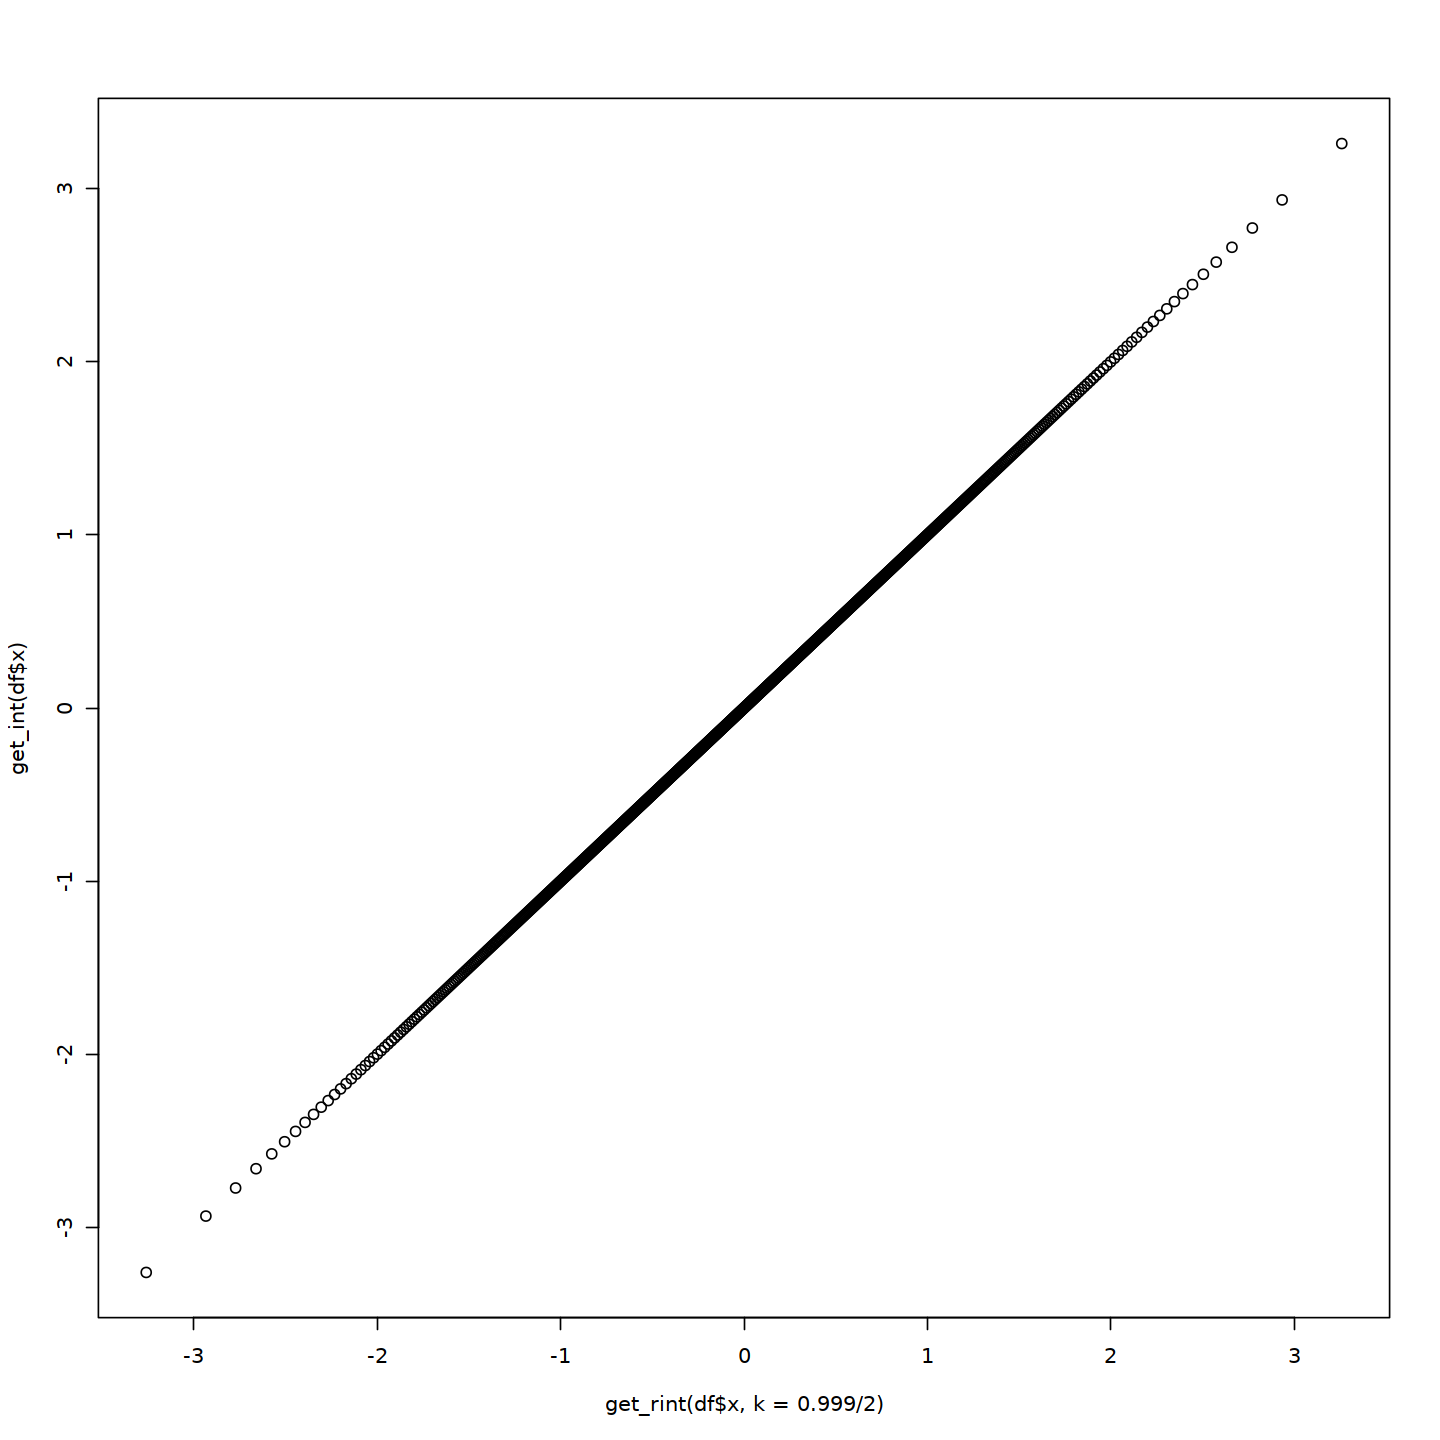

In [418]:
plot(get_rint(df$x, k = 0.999/2), get_int(df$x))

In [ ]:
def get_irnt(x, k = 3/8):
    """Inverse-rank normal transformation
    
    :param x: Continuous data to transform
    :param k: Adjustable offset" (default: Blom offset = 3/8). 
    Must be in interval (0, 1/2)
    """
    
    x_orig = np.asarray(x).copy()
    is_def = ~np.isnone(x_orig)
    x = x_orig[is_def]
    
    # Number of samples
    n = x.shape[0]
    
    # Rank of samples
    # rankdata returns 1-indexed rank
    # method='min' will give the minimum rank to tied values
    rank = stats.rankdata(x, method='min')
    
    # Transformation
    # Based on equation in this R function documentation:
    # https://cran.r-project.org/web/packages/RNOmni/vignettes/RNOmni.html#inverse-normal-transformation
    
    x_irnt = stats.norm.ppf((rank - k) / (n - 2*k + 1))
    x_orig[is_def] = x_irnt
    x_irnt = x_orig
    
    return x_irnt

In [426]:
prs <- fread("data/prs/scores/AD_combined_pgs_chrom.txt.gz")

In [427]:
head(prs)

sid,chr1,chr2,chr3,chr4,chr5,chr6,chr7,chr8,chr9,⋯,chr13,chr14,chr15,chr16,chr17,chr18,chr19,chr20,chr21,chr22
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
-14,0.19269323,0.18568741,0.03219186,0.07850720,0.02999518,-0.13879194,-0.06799231,-0.023408951,0.121755993,⋯,-0.058609121,0.02737096,-0.07535888,0.02325166,-0.069829207,-0.01427854,0.026043657,-0.030433492,-0.042961216,-0.05734645
-13,-0.04124782,0.17959533,-0.12345857,0.06995220,-0.09311451,0.04432085,0.01779102,0.001546967,-0.008567123,⋯,0.217694070,-0.05632933,0.16966782,0.07352912,-0.003474005,0.01620375,-0.140379020,0.119434458,-0.006325358,-0.02469680
-12,-0.13515456,0.05067714,-0.08095667,-0.03761521,-0.10698200,-0.16481766,0.03173914,0.040443165,0.005694465,⋯,0.028933852,0.04276421,-0.11211120,-0.02568706,0.044311001,-0.01299470,0.002683642,0.031302729,-0.007511862,-0.04745982
-11,0.04425238,0.03637206,-0.06390760,-0.02985344,0.03516748,0.98878426,-0.19733726,0.046368877,0.152124063,⋯,-0.045743742,0.04151923,-0.14082567,0.02006745,-0.001358741,0.01314071,-0.067414797,-0.042413821,0.174679690,-0.03211524
-10,-0.06095226,0.12812403,0.04834124,0.11453705,-0.08280612,-0.13956070,0.10565918,0.053554084,-0.004413975,⋯,0.002366307,0.04484242,0.05484082,-0.05067743,0.030700917,0.01602163,0.010250029,0.007165919,-0.242001310,-0.02028879
-8,-0.17366277,-0.20945207,-0.02610179,0.01802821,0.09096465,-0.04244997,0.05797591,-0.097754423,-0.147998794,⋯,0.004865890,0.01500993,-0.08230572,0.20299061,-0.017878171,0.02965019,-0.027889069,-0.134234887,-0.105260685,0.03542964


In [452]:
id_col <- colnames(prs)[1]
chroms <- colnames(prs)[-1]
stopifnot(length(chroms)==22)
lst <- lapply(chroms, function(ch){
    dt_remove_chr <- prs[,-ch, with = FALSE]
    off_chrom_prs <- rowSums(dt_remove_chr[,-1])
    return(off_chrom_prs)
})
loco_prs <- data.table(do.call(cbind, lst))
colnames(loco_prs) <- paste0('prs_not_',chroms)
loco_prs[[id_col]] <- prs[[id_col]]

In [453]:
head(loco_prs)

prs_not_chr1,prs_not_chr2,prs_not_chr3,prs_not_chr4,prs_not_chr5,prs_not_chr6,prs_not_chr7,prs_not_chr8,prs_not_chr9,prs_not_chr10,⋯,prs_not_chr14,prs_not_chr15,prs_not_chr16,prs_not_chr17,prs_not_chr18,prs_not_chr19,prs_not_chr20,prs_not_chr21,prs_not_chr22,sid
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
0.3337757,0.34078148,0.494277022,0.44796168,0.4964737,0.66526083,0.59446119,0.549877837,0.4047129,0.540891614,⋯,0.499097928,0.6018278,0.50321722,0.59629809,0.5407474,0.5004252,0.55690238,0.5694301,0.58381533,-14
0.7262206,0.50537741,0.808431312,0.61502054,0.7780873,0.64065190,0.66718173,0.683425776,0.6935399,0.655430417,⋯,0.741302069,0.5153049,0.61144362,0.68844675,0.6687690,0.8253518,0.56553829,0.6912981,0.70966954,-13
-0.3125692,-0.49840087,-0.366767067,-0.41010853,-0.3407417,-0.28290608,-0.47946288,-0.488166905,-0.4534182,-0.456794657,⋯,-0.490487947,-0.3356125,-0.42203667,-0.49203474,-0.4347290,-0.4504074,-0.47902647,-0.4402119,-0.40026392,-12
0.9740382,0.98191849,1.082198150,1.04814399,0.9831231,0.02950629,1.21562781,0.971921674,0.8661665,1.055359316,⋯,0.976771318,1.1591162,0.99822310,1.01964929,1.0051498,1.0857053,1.06070437,0.8436109,1.05040579,-11
0.1048805,-0.08419581,-0.004413017,-0.07060882,0.1267343,0.18348892,-0.06173096,-0.009625859,0.0483422,-0.002150507,⋯,-0.000914196,-0.0109126,0.09460565,0.01322731,0.0279066,0.0336782,0.03676231,0.2859295,0.06421701,-10
-0.3921366,-0.35634734,-0.539697623,-0.58382762,-0.6567641,-0.52334944,-0.62377532,-0.468044990,-0.4178006,-0.639108116,⋯,-0.580809340,-0.4834937,-0.76879002,-0.54792124,-0.5954496,-0.5379103,-0.43156453,-0.4605387,-0.60122906,-8
